# 📘 Linear Discriminant Analysis (LDA) — A Complete Guide

### From Intuition to Implementation

---

**Audience:** Freshers to Experienced Practitioners  
**Goal:** Understand LDA — theory, math, derivations, real-life applications, and end-to-end code

---

### What You'll Learn:
| # | Topic |
|---|-------|
| 1 | Import Required Libraries |
| 2 | What is LDA? — Intuition with a Visual Example |
| 3 | Mathematical Foundation — Scatter Matrices |
| 3.1 | Why We Need Both $S_B$ and $S_W$ in LDA |
| 4 | Deriving the LDA Objective (Fisher's Criterion) — Step by Step |
| 5 | Solving the Generalized Eigenvalue Problem |
| 6 | LDA from Scratch — Full Manual Implementation |
| 7 | Visualizing the LDA Projection (2D → 1D) |
| 8 | Real-Life Example 1 — Customer Segmentation |
| 9 | Real-Life Example 2 — Medical Diagnosis (Breast Cancer) |
| 10 | End-to-End LDA Pipeline Using Scikit-Learn (Wine Dataset) |
| 11 | LDA vs PCA — Head-to-Head Comparison |
| 12 | What Happens WITHOUT LDA? — The Curse of Dimensionality |
| 13 | WITH LDA — Classification on Reduced Data |
| 14 | Performance Comparison — With vs Without LDA |
| 15 | When Does LDA Fail? — Assumptions, Limitations & Explanations |
| 15b | PCA Assumptions (Often Overlooked!) |
| 16 | Multi-Class LDA — Classic Iris Dataset (End-to-End) |
| 17 | Hyperparameter Tuning — Choosing the Optimal Number of Components |
| | Summary & Key Takeaways |

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.datasets import (load_iris, load_wine, load_breast_cancer,
                               load_digits, make_classification, make_moons)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, precision_recall_fscore_support)
from sklearn.pipeline import Pipeline

# SciPy for eigenvalue computations
from scipy import linalg
import time

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. What is LDA? — Intuition with a Visual Example

---
### The Big Idea (For Everyone)

Imagine you're a teacher with students from **two classes** standing in a room. You want to draw a **single line on the floor** such that when every student steps onto that line (projects onto it), the two classes are **as far apart as possible** and students within the same class are **as close together as possible**.

> **LDA finds that optimal line (or hyperplane in higher dimensions).**

### More Formally:
- **LDA** = Linear Discriminant Analysis
- It is a **supervised** dimensionality reduction technique (it uses class labels!)
- **Goal:** Find a linear combination of features that **best separates** two or more classes
- It simultaneously:
  - **Maximizes** the distance between class means (between-class variance)
  - **Minimizes** the spread within each class (within-class variance)

### Real-Life Analogy 🍎🍊
You have a basket of **apples** and **oranges**. Each fruit has measurements: `weight`, `diameter`, `color_intensity`. LDA finds the **single best measurement direction** that makes apples look most different from oranges.

---

Let's see this visually with a 2D example:

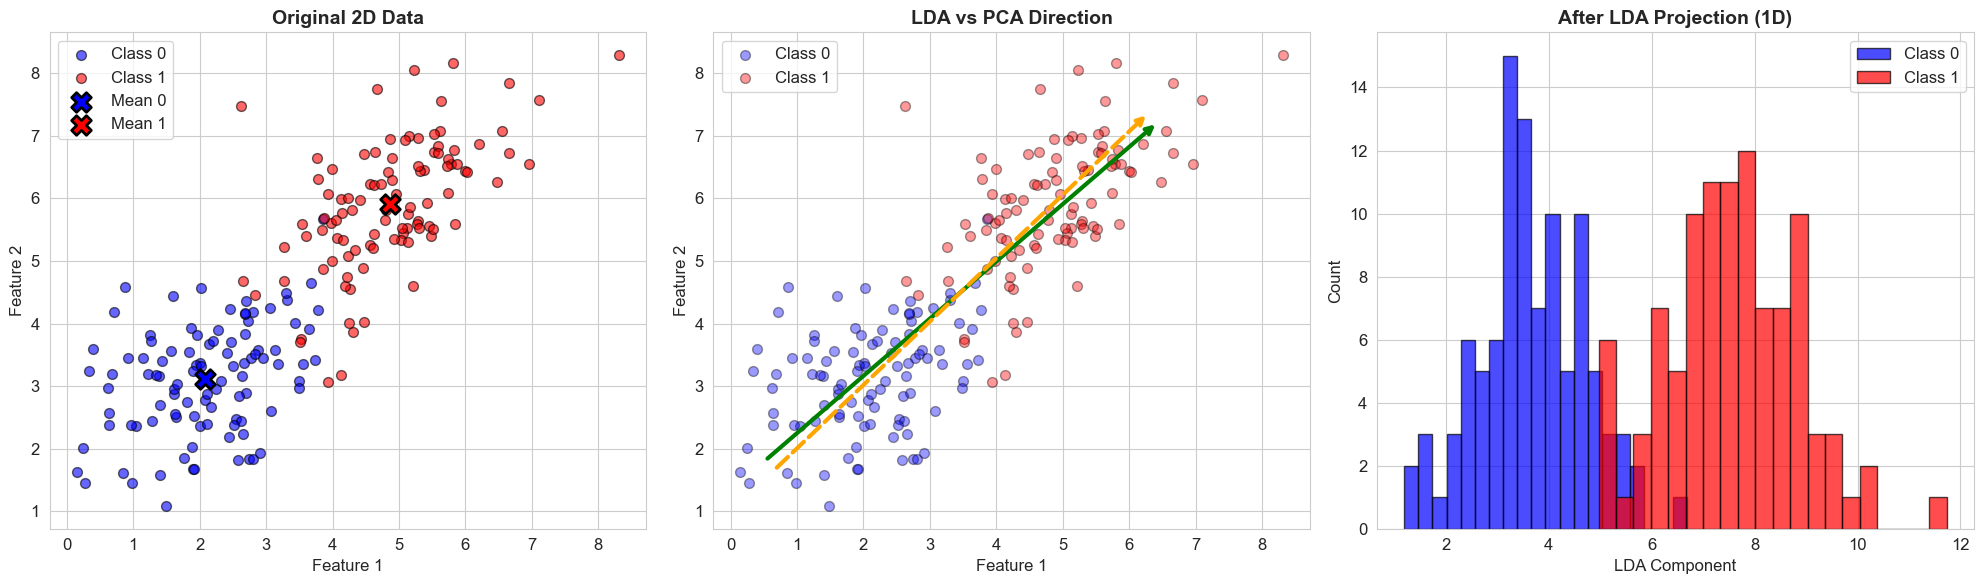

✅ Notice how the 1D LDA projection cleanly separates the two classes!
   LDA direction: [0.738, 0.675]
   PCA direction: [0.703, 0.711]


In [ ]:
# Generate a simple 2-class 2D dataset
np.random.seed(42)

# Class 0: centered around (2, 3)
class0 = np.random.multivariate_normal(mean=[2, 3], cov=[[1, 0.5], [0.5, 1]], size=100)
# Class 1: centered around (5, 6)
class1 = np.random.multivariate_normal(mean=[5, 6], cov=[[1, 0.5], [0.5, 1]], size=100)

X_demo = np.vstack([class0, class1])
y_demo = np.array([0]*100 + [1]*100)

# Compute class means and overall mean
mean0 = class0.mean(axis=0)
mean1 = class1.mean(axis=0)
overall_mean = X_demo.mean(axis=0)

# --- LDA direction (simplified for 2-class) ---
# w_lda ∝ S_W^{-1} (μ1 - μ0)
S_W = np.cov(class0.T) * (len(class0) - 1) + np.cov(class1.T) * (len(class1) - 1)
w_lda = np.linalg.inv(S_W) @ (mean1 - mean0)
w_lda = w_lda / np.linalg.norm(w_lda)  # normalize

# --- PCA direction (for comparison) ---
pca = PCA(n_components=1)
pca.fit(X_demo)
w_pca = pca.components_[0]
w_pca = w_pca / np.linalg.norm(w_pca)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Original data
axes[0].scatter(class0[:, 0], class0[:, 1], c='blue', alpha=0.6, label='Class 0', edgecolors='k', s=50)
axes[0].scatter(class1[:, 0], class1[:, 1], c='red', alpha=0.6, label='Class 1', edgecolors='k', s=50)
axes[0].scatter(*mean0, c='blue', marker='X', s=200, edgecolors='black', linewidths=2, label='Mean 0')
axes[0].scatter(*mean1, c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Mean 1')
axes[0].set_title('Original 2D Data', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Plot 2: Data with LDA direction
axes[1].scatter(class0[:, 0], class0[:, 1], c='blue', alpha=0.4, edgecolors='k', s=50)
axes[1].scatter(class1[:, 0], class1[:, 1], c='red', alpha=0.4, edgecolors='k', s=50)
# Draw LDA direction arrow
origin = overall_mean
axes[1].annotate('', xy=origin + w_lda * 4, xytext=origin - w_lda * 4,
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
axes[1].annotate('', xy=origin + w_pca * 4, xytext=origin - w_pca * 4,
                arrowprops=dict(arrowstyle='->', color='orange', lw=3, linestyle='--'))
axes[1].set_title('LDA vs PCA Direction', fontsize=14, fontweight='bold')
axes[1].legend(['Class 0', 'Class 1', 'LDA direction', 'PCA direction'])
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# Plot 3: Projected data on LDA axis (1D histogram)
proj_class0 = class0 @ w_lda
proj_class1 = class1 @ w_lda
axes[2].hist(proj_class0, bins=20, alpha=0.7, color='blue', label='Class 0', edgecolor='black')
axes[2].hist(proj_class1, bins=20, alpha=0.7, color='red', label='Class 1', edgecolor='black')
axes[2].set_title('After LDA Projection (1D)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('LDA Component')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print("✅ Notice how the 1D LDA projection cleanly separates the two classes!")
print(f"   LDA direction: [{w_lda[0]:.3f}, {w_lda[1]:.3f}]")
print(f"   PCA direction: [{w_pca[0]:.3f}, {w_pca[1]:.3f}]")

## 3. Mathematical Foundation — Scatter Matrices

---

### Key Notation

| Symbol | Meaning |
|--------|---------|
| $C$ | Number of classes |
| $C_i$ | Set of samples in class $i$ |
| $N_i$ | Number of samples in class $i$ |
| $N$ | Total number of samples |
| $\mu_i$ | Mean vector of class $i$ |
| $\mu$ | Overall mean vector |
| $d$ | Number of features (dimensions) |

### Within-Class Scatter Matrix ($S_W$)

Measures how much the data points within each class **scatter around their own class mean**:

$$S_W = \sum_{i=1}^{C} S_i = \sum_{i=1}^{C} \sum_{\mathbf{x} \in C_i} (\mathbf{x} - \boldsymbol{\mu}_i)(\mathbf{x} - \boldsymbol{\mu}_i)^T$$

> **Intuition:** If $S_W$ is small, each class is tightly packed — that's good for separation!

### Between-Class Scatter Matrix ($S_B$)

Measures how far apart the **class means** are from the **overall mean**:

$$S_B = \sum_{i=1}^{C} N_i (\boldsymbol{\mu}_i - \boldsymbol{\mu})(\boldsymbol{\mu}_i - \boldsymbol{\mu})^T$$

> **Intuition:** If $S_B$ is large, the class centers are far apart — that's also good for separation!

### Total Scatter Matrix

$$S_T = S_W + S_B = \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^T$$

---

Let's compute these step by step:

In [ ]:
# Using the same 2-class demo data from above
print("=" * 60)
print("STEP-BY-STEP: Computing Scatter Matrices")
print("=" * 60)

# Step 1: Class means and overall mean
print(f"\n📌 Class 0 mean (μ₀): {mean0}")
print(f"📌 Class 1 mean (μ₁): {mean1}")
print(f"📌 Overall mean (μ) : {overall_mean}")
print(f"📌 N₀ = {len(class0)}, N₁ = {len(class1)}, N = {len(X_demo)}")

# Step 2: Within-Class Scatter Matrix S_W
print("\n" + "-" * 60)
print("WITHIN-CLASS SCATTER MATRIX (S_W)")
print("-" * 60)

S_0 = np.zeros((2, 2))
for x in class0:
    diff = (x - mean0).reshape(-1, 1)
    S_0 += diff @ diff.T

S_1 = np.zeros((2, 2))
for x in class1:
    diff = (x - mean1).reshape(-1, 1)
    S_1 += diff @ diff.T

S_W = S_0 + S_1

print(f"\nS₀ (scatter of class 0):\n{S_0}")
print(f"\nS₁ (scatter of class 1):\n{S_1}")
print(f"\nS_W = S₀ + S₁:\n{S_W}")

# Step 3: Between-Class Scatter Matrix S_B
print("\n" + "-" * 60)
print("BETWEEN-CLASS SCATTER MATRIX (S_B)")
print("-" * 60)

S_B = np.zeros((2, 2))
for n_i, mean_i in [(len(class0), mean0), (len(class1), mean1)]:
    diff = (mean_i - overall_mean).reshape(-1, 1)
    S_B += n_i * (diff @ diff.T)

print(f"\nS_B:\n{S_B}")

# Step 4: Verify S_T = S_W + S_B
S_T = np.zeros((2, 2))
for x in X_demo:
    diff = (x - overall_mean).reshape(-1, 1)
    S_T += diff @ diff.T

print(f"\n{'=' * 60}")
print("VERIFICATION: S_T = S_W + S_B")
print(f"{'=' * 60}")
print(f"\nS_T (computed directly):\n{S_T}")
print(f"\nS_W + S_B:\n{S_W + S_B}")
print(f"\n✅ Match: {np.allclose(S_T, S_W + S_B)}")

STEP-BY-STEP: Computing Scatter Matrices

📌 Class 0 mean (μ₀): [2.08307042 3.11709274]
📌 Class 1 mean (μ₁): [4.86718952 5.91067717]
📌 Overall mean (μ) : [3.47512997 4.51388496]
📌 N₀ = 100, N₁ = 100, N = 200

------------------------------------------------------------
WITHIN-CLASS SCATTER MATRIX (S_W)
------------------------------------------------------------

S₀ (scatter of class 0):
[[81.50928964 29.75193857]
 [29.75193857 76.76871081]]

S₁ (scatter of class 1):
[[ 94.90689547  58.61711061]
 [ 58.61711061 108.8366447 ]]

S_W = S₀ + S₁:
[[176.41618511  88.36904918]
 [ 88.36904918 185.60535551]]

------------------------------------------------------------
BETWEEN-CLASS SCATTER MATRIX (S_B)
------------------------------------------------------------

S_B:
[[387.56595918 388.88358875]
 [388.88358875 390.20569794]]

VERIFICATION: S_T = S_W + S_B

S_T (computed directly):
[[563.98214429 477.25263793]
 [477.25263793 575.81105345]]

S_W + S_B:
[[563.98214429 477.25263793]
 [477.25263793 

## 3.1 Why We Need Both $S_B$ and $S_W$ in LDA

---

### The Problem: Two Competing Goals

Imagine you're designing a classification system. You face a **fundamental trade-off**:

| Goal | What it means | Example |
|------|--------------|---------|
| **Maximize separation** | Push class means far apart | Classes don't overlap |
| **Minimize scatter** | Keep points within classes tight | Low within-class noise |

If you only chase one goal, you fail:

### ❌ If We Only Used $S_B$ (Between-Class Scatter)

Maximize: $\max_{\mathbf{w}} \mathbf{w}^T S_B \mathbf{w}$

```python
# What happens?
# The algorithm says: "Make the class means as far apart as possible!"
# But it doesn't care if each class is a messy cloud spreading everywhere.

# Example: 2 classes
# Class 0: scattered all over the place (but mean is at point A)
# Class 1: scattered all over the place (but mean is at point B)
#
# If A and B are far apart → S_B is maximized ✓
# But Class 0 and Class 1 might still OVERLAP massively ✗
```


### ❌ If We Only Used $S_W$ (Within-Class Scatter)

Minimize: $\min_{\mathbf{w}} \mathbf{w}^T S_W \mathbf{w}$

```python
# What happens?
# The algorithm says: "Make points within each class cluster tightly!"
# But it doesn't care if the classes are far from each other.

# Example:
# We find a direction where Class 0 is super tight AND Class 1 is super tight.
# But they're at the SAME location!
#
# Tight clustering ✓, but classes are stacked on top of each other ✗
# Classification accuracy = 50% (random guessing)
```



---

### ✅ The Solution: Balance Both with Fisher's Criterion

LDA uses **both** by creating a ratio:

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}} = \frac{\text{Between-class separation}}{\text{Within-class scatter}}$$

**What this means:**
- **Numerator** ($S_B$): Keep classes far apart
- **Denominator** ($S_W$): Keep each class compact
- **The ratio:** Balance these two goals
- **w** is eigen vector

Maximizing this ratio means:
- Classes are **well-separated** (large numerator)
- **AND** each class is **tightly clustered** (small denominator)

---

![image.png](attachment:image.png)

## 4. Deriving the LDA Objective (Fisher's Criterion) — Step by Step

---


### First, let's define everything clearly

**The data:**
- We have $C$ classes. Each class $c$ has $n_c$ data points.
- $\mu_c$ = mean of class $c$ (average of all points in that class)
- $\mu$ = overall mean (average of ALL points across all classes)
- $\mathbf{w}$ = the direction we want to project data onto (this is what we're trying to find)

**Within-class scatter matrix** $S_W$ — measures how spread out points are **inside each class**:

$$S_W = \sum_{c=1}^{C} \sum_{\mathbf{x} \in \text{class } c} (\mathbf{x} - \mu_c)(\mathbf{x} - \mu_c)^T$$

For each point, compute how far it is from its own class mean. Multiply that difference by itself (outer product). Sum over all points in all classes.

**Between-class scatter matrix** $S_B$ — measures how far apart the **class means** are from each other:

$$S_B = \sum_{c=1}^{C} n_c \;(\mu_c - \mu)(\mu_c - \mu)^T$$

For each class, compute how far its mean is from the overall mean. Multiply by itself. Weight by the number of points in that class. Sum over all classes.

Both $S_W$ and $S_B$ are matrices of size (number of features × number of features).

**Why the transpose multiplication $(\mathbf{x} - \mu_c)(\mathbf{x} - \mu_c)^T$?**

$(\mathbf{x} - \mu_c)$ is a column vector of size $(d \times 1)$ — it just tells you how far one point is from its class mean. We need to turn this vector into a **matrix** because:

| Expression | Shapes | Result |
|---|---|---|
| $(\mathbf{x} - \mu_c)^T(\mathbf{x} - \mu_c)$ | $(1 \times d) \cdot (d \times 1)$ | **1 number** — just total squared distance, loses per-feature detail |
| $(\mathbf{x} - \mu_c)(\mathbf{x} - \mu_c)^T$ | $(d \times 1) \cdot (1 \times d)$ | **$d \times d$ matrix** — stores spread in all directions at once |

The $d \times d$ matrix captures:
- **Diagonal entries** = how much each feature spreads on its own (variance)
- **Off-diagonal entries** = how features move together (covariance) — e.g., do students who score high in Math also score high in Science?

We need this full map because at this stage **we don't know $\mathbf{w}$ yet** (we haven't done the derivation). The matrix stores the spread information for **every possible direction**. Later, when we solve the eigenvalue equation and get the actual $\mathbf{w}$, we plug it into $\mathbf{w}^T S_W \mathbf{w}$ to extract the spread for that specific direction.

---

### Example: What are $\mathbf{x}$, $\mu_c$, and $\mu$?

6 students, 2 features (Math, Science), 2 classes (Pass, Fail):

| Student | Math | Science | Class |
|---|---|---|---|
| S1 | 80 | 70 | Pass |
| S2 | 90 | 85 | Pass |
| S3 | 85 | 75 | Pass |
| S4 | 40 | 35 | Fail |
| S5 | 30 | 45 | Fail |
| S6 | 35 | 40 | Fail |

**$\mathbf{x}$** = one student's data written as a vector. For example, Student 1:

$$\mathbf{x}_1 = \begin{bmatrix} 80 \\ 70 \end{bmatrix}$$

It's just one row of data written as a column.

**$\mu_c$** = mean of class $c$. Average each feature **within that class only**:

$$\mu_{\text{Pass}} = \frac{1}{3}\begin{bmatrix} 80+90+85 \\ 70+85+75 \end{bmatrix} = \begin{bmatrix} 85 \\ 76.67 \end{bmatrix} \qquad \mu_{\text{Fail}} = \frac{1}{3}\begin{bmatrix} 40+30+35 \\ 35+45+40 \end{bmatrix} = \begin{bmatrix} 35 \\ 40 \end{bmatrix}$$

**$\mu$** = overall mean. Average each feature across **ALL students** (ignore classes):

$$\mu = \frac{1}{6}\begin{bmatrix} 80+90+85+40+30+35 \\ 70+85+75+35+45+40 \end{bmatrix} = \begin{bmatrix} 60 \\ 58.33 \end{bmatrix}$$

Then in the scatter matrices:
- $(\mathbf{x} - \mu_c)$ = how far a student is from **their own class's average** → used in $S_W$
- $(\mu_c - \mu)$ = how far a class average is from the **overall average** → used in $S_B$

**Now let's compute $S_W$ and $S_B$ for this data:**

**$S_W$ (within-class scatter):** For each student, compute $(\mathbf{x} - \mu_c)(\mathbf{x} - \mu_c)^T$ and sum them up.

Pass class (each student minus $\mu_{\text{Pass}} = [85, 76.67]$):

$$S_{\text{Pass}} = \underbrace{\begin{bmatrix} -5 \\ -6.67 \end{bmatrix}\begin{bmatrix} -5 & -6.67 \end{bmatrix}}_{\text{S1}} + \underbrace{\begin{bmatrix} 5 \\ 8.33 \end{bmatrix}\begin{bmatrix} 5 & 8.33 \end{bmatrix}}_{\text{S2}} + \underbrace{\begin{bmatrix} 0 \\ -1.67 \end{bmatrix}\begin{bmatrix} 0 & -1.67 \end{bmatrix}}_{\text{S3}} = \begin{bmatrix} 50 & 75 \\ 75 & 116.67 \end{bmatrix}$$

Fail class (each student minus $\mu_{\text{Fail}} = [35, 40]$):

$$S_{\text{Fail}} = \underbrace{\begin{bmatrix} 5 \\ -5 \end{bmatrix}\begin{bmatrix} 5 & -5 \end{bmatrix}}_{\text{S4}} + \underbrace{\begin{bmatrix} -5 \\ 5 \end{bmatrix}\begin{bmatrix} -5 & 5 \end{bmatrix}}_{\text{S5}} + \underbrace{\begin{bmatrix} 0 \\ 0 \end{bmatrix}\begin{bmatrix} 0 & 0 \end{bmatrix}}_{\text{S6}} = \begin{bmatrix} 50 & -50 \\ -50 & 50 \end{bmatrix}$$

$$S_W = S_{\text{Pass}} + S_{\text{Fail}} = \begin{bmatrix} 100 & 25 \\ 25 & 166.67 \end{bmatrix}$$

**$S_B$ (between-class scatter):** For each class, compute $n_c(\mu_c - \mu)(\mu_c - \mu)^T$ and sum.

$$S_B = 3\begin{bmatrix} 25 \\ 18.33 \end{bmatrix}\begin{bmatrix} 25 & 18.33 \end{bmatrix} + 3\begin{bmatrix} -25 \\ -18.33 \end{bmatrix}\begin{bmatrix} -25 & -18.33 \end{bmatrix} = \begin{bmatrix} 3750 & 2750 \\ 2750 & 2016.67 \end{bmatrix}$$

**Now we have $S_W$ and $S_B$. What is $\mathbf{w}$?**

$\mathbf{w} = \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}$ — **unknown**. This is what we're trying to find. The ratio becomes:

$$J(\mathbf{w}) = \frac{[w_1, w_2] \begin{bmatrix} 3750 & 2750 \\ 2750 & 2016.67 \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}}{[w_1, w_2] \begin{bmatrix} 100 & 25 \\ 25 & 166.67 \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}} = \frac{3750w_1^2 + 5500w_1w_2 + 2016.67w_2^2}{100w_1^2 + 50w_1w_2 + 166.67w_2^2}$$

The derivation below finds the $w_1, w_2$ that make this ratio as large as possible.

---

### The Objective

Find the direction $\mathbf{w}$ that **maximizes**:

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

- **Top** ($\mathbf{w}^T S_B \mathbf{w}$): how far apart the class means are **after projecting onto $\mathbf{w}$**. This is a single number.
- **Bottom** ($\mathbf{w}^T S_W \mathbf{w}$): how spread out the points are within each class **after projecting onto $\mathbf{w}$**. Also a single number.

So $J(\mathbf{w})$ = (separation between classes) / (spread within classes). We want this ratio to be as large as possible.

**Why $\mathbf{w}^T$ and $\mathbf{w}$ (not just $\mathbf{w}$)?** It's about dimensions. $\mathbf{w}$ is a column vector of shape $(d \times 1)$. $S_B$ is a $(d \times d)$ matrix. If you just wrote $S_B \mathbf{w}$, you'd get a $(d \times 1)$ vector — you can't divide a vector by a vector. Multiplying by $\mathbf{w}^T$ (shape $1 \times d$) on the left collapses it to a single number:

$$\underbrace{\mathbf{w}^T}_{(1 \times d)} \;\underbrace{S_B}_{(d \times d)} \;\underbrace{\mathbf{w}}_{(d \times 1)} = \underbrace{\text{scalar}}_{(1 \times 1)}$$

This is just the matrix way of computing a dot product.

---

### How to Maximize a Function?

From school calculus: **take the derivative, set it to zero, solve.**

Example: maximize $f(x) = -x^2 + 4x$
- Derivative: $f'(x) = -2x + 4$
- Set to zero: $-2x + 4 = 0$ → $x = 2$

We do the same thing here, but with vectors instead of $x$.

---

### One Formula You Need (Matrix Calculus)

In regular calculus: $\frac{d}{dx}(x^2) = 2x$

The matrix version: $\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T A \mathbf{w}) = 2A\mathbf{w}$ (where $A$ is a symmetric matrix)

Just accept this like you accept $\frac{d}{dx}(x^2) = 2x$. Using this:

- $\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T S_B \mathbf{w}) = 2 S_B \mathbf{w}$
- $\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T S_W \mathbf{w}) = 2 S_W \mathbf{w}$

---

### The Derivation (5 Steps)

**Step 1 — Apply the quotient rule.**

$J(\mathbf{w})$ is a fraction. From school: if $h = \frac{f}{g}$, then $h' = \frac{f' \cdot g - g' \cdot f}{g^2}$

Let:
- $f = \mathbf{w}^T S_B \mathbf{w}$ → $f' = 2 S_B \mathbf{w}$
- $g = \mathbf{w}^T S_W \mathbf{w}$ → $g' = 2 S_W \mathbf{w}$

So:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{(2 S_B \mathbf{w}) \cdot (\mathbf{w}^T S_W \mathbf{w}) \;-\; (2 S_W \mathbf{w}) \cdot (\mathbf{w}^T S_B \mathbf{w})}{(\mathbf{w}^T S_W \mathbf{w})^2}$$

Note: $\mathbf{w}^T S_B \mathbf{w}$ and $\mathbf{w}^T S_W \mathbf{w}$ are just numbers (scalars), so they can be multiplied freely with vectors.

---

**Step 2 — Set the derivative to zero.**

A fraction equals zero when the **numerator equals zero** (the denominator $(\mathbf{w}^T S_W \mathbf{w})^2$ is always positive, never zero):

$$(2 S_B \mathbf{w}) \cdot (\mathbf{w}^T S_W \mathbf{w}) \;-\; (2 S_W \mathbf{w}) \cdot (\mathbf{w}^T S_B \mathbf{w}) = 0$$

Cancel the 2 from both terms:

$$S_B \mathbf{w} \cdot (\mathbf{w}^T S_W \mathbf{w}) = S_W \mathbf{w} \cdot (\mathbf{w}^T S_B \mathbf{w})$$

Divide both sides by $(\mathbf{w}^T S_W \mathbf{w})$, which is just a number:

$$S_B \mathbf{w} = S_W \mathbf{w} \cdot \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

---

**Step 3 — Recognize the ratio.**

Look at $\frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$ — that's exactly $J(\mathbf{w})$! Call it $\lambda$ (it's just a number):

$$S_B \mathbf{w} = \lambda \; S_W \mathbf{w}$$

---

**Step 4 — Isolate $\mathbf{w}$.**

Multiply both sides on the left by $S_W^{-1}$ (the inverse of $S_W$):

$$S_W^{-1} S_B \mathbf{w} = \lambda \; S_W^{-1} S_W \mathbf{w}$$

Since $S_W^{-1} S_W = I$ (identity matrix, like dividing a number by itself gives 1):

$$\boxed{S_W^{-1} S_B \mathbf{w} = \lambda \; \mathbf{w}}$$

---

**Step 5 — This is an eigenvalue equation.**

The form $A\mathbf{w} = \lambda \mathbf{w}$ is the standard eigenvalue equation, where $A = S_W^{-1} S_B$.

Solving this gives us:
- **Eigenvectors** ($\mathbf{w}$): the directions to project data onto — these are the LDA components
- **Eigenvalues** ($\lambda$): how good the separation is along each direction

Pick the eigenvector with the **largest** $\lambda$ → that's LD1 (the direction with the best class separation).

If you need $k$ components, pick the $k$ eigenvectors with the $k$ largest eigenvalues.

---

### Why Larger Eigenvalue = Better Separation

From Step 3: $\lambda = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$

The eigenvalue **IS** the value of $J(\mathbf{w})$ for that direction. It equals:

$$\lambda = \frac{\text{between-class scatter along } \mathbf{w}}{\text{within-class scatter along } \mathbf{w}}$$

| Eigenvalue | Between-class (top) | Within-class (bottom) | Result |
|---|---|---|---|
| Large $\lambda$ | Class means far apart | Classes are tight/compact | Clear separation |
| Small $\lambda$ | Class means close | Classes are spread out | Heavy overlap |
| $\lambda = 0$ | Class means at same spot | — | No separation at all |

---

Let's verify this — we'll compute $J(\mathbf{w})$ for every possible direction and see that LDA picks the best one:

In [ ]:
# ================================================================
# VERIFYING THE DERIVATION WITH ACTUAL NUMBERS
# ================================================================
# Simple dataset: 2 classes, 2 features, 4 points each

class_A = np.array([[1, 2], [2, 3], [3, 3], [2, 2]])
class_B = np.array([[6, 7], [7, 8], [8, 7], [7, 7]])

X_all = np.vstack([class_A, class_B])
y_all = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# --- Compute S_W and S_B ---
mu_A = class_A.mean(axis=0)
mu_B = class_B.mean(axis=0)
mu = X_all.mean(axis=0)

S_W_d = sum((x - mu_A).reshape(-1,1) @ (x - mu_A).reshape(1,-1) for x in class_A) + \
        sum((x - mu_B).reshape(-1,1) @ (x - mu_B).reshape(1,-1) for x in class_B)

S_B_d = len(class_A) * (mu_A - mu).reshape(-1,1) @ (mu_A - mu).reshape(1,-1) + \
        len(class_B) * (mu_B - mu).reshape(-1,1) @ (mu_B - mu).reshape(1,-1)

print("Given:")
print(f"  Class A points: {class_A.tolist()}")
print(f"  Class B points: {class_B.tolist()}")
print(f"  μ_A = {mu_A},  μ_B = {mu_B}")
print(f"\n  S_W = \n{S_W_d}")
print(f"\n  S_B = \n{S_B_d}")

# --- Solve S_W⁻¹ S_B w = λ w ---
A_mat = np.linalg.inv(S_W_d) @ S_B_d
eig_vals, eig_vecs = np.linalg.eig(A_mat)

# Sort by eigenvalue (descending)
idx = np.argsort(eig_vals.real)[::-1]
eig_vals = eig_vals.real[idx]
eig_vecs = eig_vecs.real[:, idx]

print(f"\n--- Solving S_W⁻¹ S_B w = λw ---")
print(f"\n  S_W⁻¹ S_B = \n{A_mat.round(4)}")
print(f"\n  Results:")
print(f"    λ₁ = {eig_vals[0]:.4f},  w₁ = {eig_vecs[:, 0].round(4)}")
print(f"    λ₂ = {eig_vals[1]:.4f},  w₂ = {eig_vecs[:, 1].round(4)}")
print(f"\n  → w₁ is the best direction (highest λ)")
print(f"  → w₂ is useless (λ ≈ 0, no separation along that direction)")

Given:
  Class A points: [[1, 2], [2, 3], [3, 3], [2, 2]]
  Class B points: [[6, 7], [7, 8], [8, 7], [7, 7]]
  μ_A = [2.  2.5],  μ_B = [7.   7.25]

  S_W = 
[[4.   1.  ]
 [1.   1.75]]

  S_B = 
[[50.    47.5  ]
 [47.5   45.125]]

--- Solving S_W⁻¹ S_B w = λw ---

  S_W⁻¹ S_B = 
[[ 6.6667  6.3333]
 [23.3333 22.1667]]

  Results:
    λ₁ = 28.8333,  w₁ = [-0.2747 -0.9615]
    λ₂ = 0.0000,  w₂ = [-0.6887  0.725 ]

  → w₁ is the best direction (highest λ)
  → w₂ is useless (λ ≈ 0, no separation along that direction)


In [ ]:
# ================================================================
# VERIFY: Eigenvalue = J(w) for that direction
# ================================================================

w1 = eig_vecs[:, 0]

# Compute J(w1) manually using the formula
numerator = w1.T @ S_B_d @ w1    # between-class scatter along w1
denominator = w1.T @ S_W_d @ w1  # within-class scatter along w1
J_w1 = numerator / denominator

print("Verifying: does λ₁ equal J(w₁)?")
print(f"  w₁ᵀ S_B w₁ (between-class) = {numerator:.4f}")
print(f"  w₁ᵀ S_W w₁ (within-class)  = {denominator:.4f}")
print(f"  J(w₁) = {numerator:.4f} / {denominator:.4f} = {J_w1:.4f}")
print(f"  λ₁ = {eig_vals[0]:.4f}")
print(f"  Match? {np.isclose(J_w1, eig_vals[0])} ✅")
print(f"\n→ The eigenvalue IS the Fisher criterion value for that direction.")

Verifying: does λ₁ equal J(w₁)?
  w₁ᵀ S_B w₁ (between-class) = 70.5873
  w₁ᵀ S_W w₁ (within-class)  = 2.4481
  J(w₁) = 70.5873 / 2.4481 = 28.8333
  λ₁ = 28.8333
  Match? True ✅

→ The eigenvalue IS the Fisher criterion value for that direction.


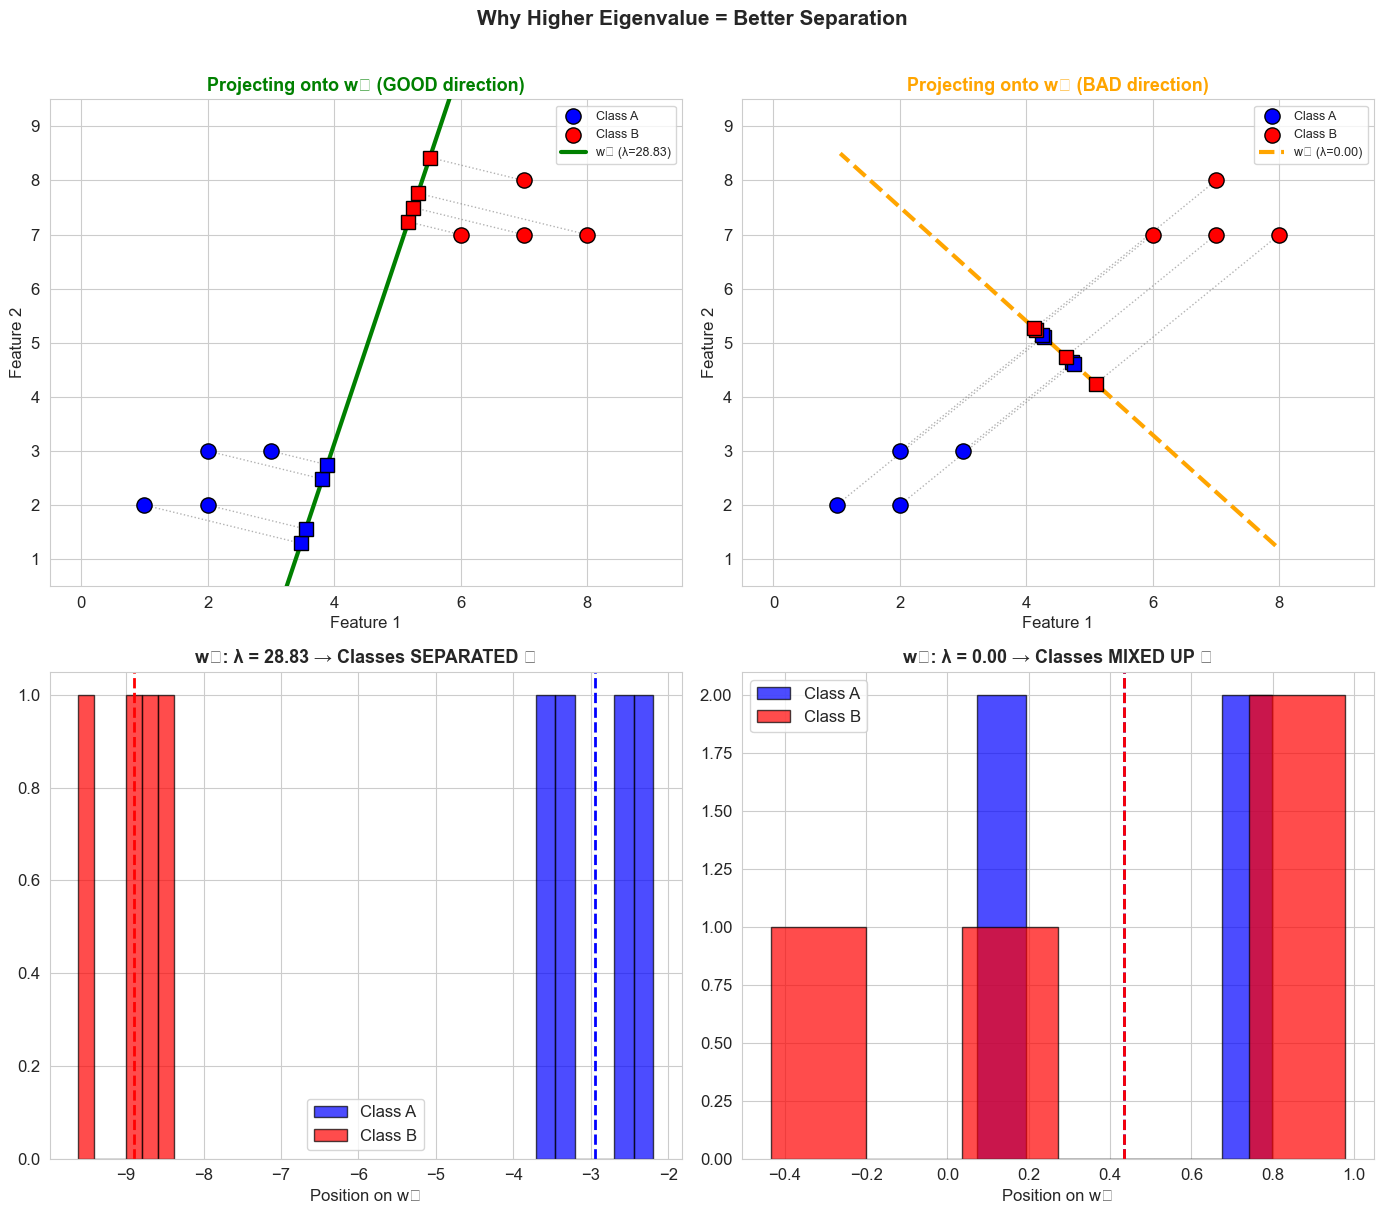

Look at the TOP plots:
  Left:  Blue ■ and Red ■ land in DIFFERENT spots on the green line → separated
  Right: Blue ■ and Red ■ land in the SAME spot on the orange line → mixed up

LDA picks w₁ (λ=28.83) because it separates the classes.


In [ ]:
# ================================================================
# VISUALIZE: w1 (high λ) vs w2 (low λ) — what does the separation look like?
# ================================================================

w1_n = eig_vecs[:, 0] / np.linalg.norm(eig_vecs[:, 0])
w2_n = eig_vecs[:, 1] / np.linalg.norm(eig_vecs[:, 1])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ------ Plot 1 (top-left): Project onto w1 (GREEN line) ------
axes[0, 0].scatter(class_A[:, 0], class_A[:, 1], c='blue', s=120, edgecolors='k', label='Class A', zorder=5)
axes[0, 0].scatter(class_B[:, 0], class_B[:, 1], c='red', s=120, edgecolors='k', label='Class B', zorder=5)
t = np.linspace(-5, 5, 100)
axes[0, 0].plot(mu[0] + t*w1_n[0], mu[1] + t*w1_n[1], 'g-', lw=3, label=f'w₁ (λ={eig_vals[0]:.2f})', zorder=3)
# Show where each point "drops" onto the green line
for pt, color in [(class_A, 'blue'), (class_B, 'red')]:
    for p in pt:
        proj_val = np.dot(p, w1_n)
        proj_point = proj_val * w1_n  # point on the line (from origin)
        # The line passes through mu, so projected point = mu + (dot(p-mu, w1_n)) * w1_n...
        # but for visualization, let's just show the landing spot on the line
        proj_on_line = mu + np.dot(p - mu, w1_n) * w1_n
        axes[0, 0].plot(*proj_on_line, 's', color=color, markersize=10, markeredgecolor='k', zorder=6)
        axes[0, 0].plot([p[0], proj_on_line[0]], [p[1], proj_on_line[1]],
                       color='gray', lw=1, linestyle=':', alpha=0.6)
all_x = np.concatenate([class_A[:, 0], class_B[:, 0]])
all_y = np.concatenate([class_A[:, 1], class_B[:, 1]])
axes[0, 0].set_xlim(all_x.min() - 1.5, all_x.max() + 1.5)
axes[0, 0].set_ylim(all_y.min() - 1.5, all_y.max() + 1.5)
axes[0, 0].set_title('Projecting onto w₁ (GOOD direction)', fontsize=13, fontweight='bold', color='green')
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')

# ------ Plot 2 (top-right): Project onto w2 (ORANGE line) ------
axes[0, 1].scatter(class_A[:, 0], class_A[:, 1], c='blue', s=120, edgecolors='k', label='Class A', zorder=5)
axes[0, 1].scatter(class_B[:, 0], class_B[:, 1], c='red', s=120, edgecolors='k', label='Class B', zorder=5)
axes[0, 1].plot(mu[0] + t*w2_n[0], mu[1] + t*w2_n[1], color='orange', lw=3, linestyle='--', label=f'w₂ (λ={eig_vals[1]:.2f})', zorder=3)
# Show where each point "drops" onto the orange line
for pt, color in [(class_A, 'blue'), (class_B, 'red')]:
    for p in pt:
        proj_on_line = mu + np.dot(p - mu, w2_n) * w2_n
        axes[0, 1].plot(*proj_on_line, 's', color=color, markersize=10, markeredgecolor='k', zorder=6)
        axes[0, 1].plot([p[0], proj_on_line[0]], [p[1], proj_on_line[1]],
                       color='gray', lw=1, linestyle=':', alpha=0.6)
axes[0, 1].set_xlim(all_x.min() - 1.5, all_x.max() + 1.5)
axes[0, 1].set_ylim(all_y.min() - 1.5, all_y.max() + 1.5)
axes[0, 1].set_title('Projecting onto w₂ (BAD direction)', fontsize=13, fontweight='bold', color='orange')
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')

# ------ Plot 3 (bottom-left): Histogram on w1 ------
proj_A1 = class_A @ w1_n
proj_B1 = class_B @ w1_n
axes[1, 0].hist(proj_A1, bins=6, alpha=0.7, color='blue', label='Class A', edgecolor='black')
axes[1, 0].hist(proj_B1, bins=6, alpha=0.7, color='red', label='Class B', edgecolor='black')
axes[1, 0].axvline(proj_A1.mean(), color='blue', linestyle='--', lw=2)
axes[1, 0].axvline(proj_B1.mean(), color='red', linestyle='--', lw=2)
axes[1, 0].set_title(f'w₁: λ = {eig_vals[0]:.2f} → Classes SEPARATED ✅', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Position on w₁')

# ------ Plot 4 (bottom-right): Histogram on w2 ------
proj_A2 = class_A @ w2_n
proj_B2 = class_B @ w2_n
axes[1, 1].hist(proj_A2, bins=6, alpha=0.7, color='blue', label='Class A', edgecolor='black')
axes[1, 1].hist(proj_B2, bins=6, alpha=0.7, color='red', label='Class B', edgecolor='black')
axes[1, 1].axvline(proj_A2.mean(), color='blue', linestyle='--', lw=2)
axes[1, 1].axvline(proj_B2.mean(), color='red', linestyle='--', lw=2)
axes[1, 1].set_title(f'w₂: λ = {eig_vals[1]:.2f} → Classes MIXED UP ❌', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Position on w₂')

plt.suptitle('Why Higher Eigenvalue = Better Separation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Look at the TOP plots:")
print("  Left:  Blue ■ and Red ■ land in DIFFERENT spots on the green line → separated")
print("  Right: Blue ■ and Red ■ land in the SAME spot on the orange line → mixed up")
print(f"\nLDA picks w₁ (λ={eig_vals[0]:.2f}) because it separates the classes.")

## 5. Solving the Generalized Eigenvalue Problem

---


### From the Derivation
We showed that maximizing Fisher's criterion leads to:

$$S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$$

### How to Solve It
1. Compute $S_W^{-1} S_B$ (a $d \times d$ matrix)
2. Find its **eigenvalues** $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$ and corresponding **eigenvectors** $\mathbf{w}_1, \mathbf{w}_2, \ldots, \mathbf{w}_d$
3. Select the top $k$ eigenvectors (corresponding to the $k$ largest eigenvalues)
4. These $k$ eigenvectors form the **LDA projection matrix** $W \in \mathbb{R}^{d \times k}$

### Important Constraint
> **Maximum number of LDA components** = $\min(C - 1, \; d)$
>
> where $C$ = number of classes, $d$ = number of features

**Why $C - 1$?** Because $S_B$ has rank at most $C - 1$ (it's a sum of $C$ rank-1 matrices, but constrained by $\sum N_i(\mu_i - \mu) = 0$).
* LDA looks for axes that separate class means
* If you have C classes, you have C mean vectors
* Any set of C points in a high-dimensional space can be perfectly contained within a flat subspace of at most C- 1 dimensions.

**Why d ? (The Feature Limit)** :
* The number of components cannot exceed the original number of features (d) because you cannot create more independent directions for projection than the number of dimensions you started with

| Classes | Features | Max LDA Components |
|---------|----------|--------------------|
| 2       | 10       | min(1, 10) = **1** |
| 3       | 4        | min(2, 4) = **2** |
| 5       | 3        | min(4, 3) = **3** |
| 10      | 50       | min(9, 50) = **9** |

In [ ]:
# Solve the eigenvalue problem: S_W^{-1} S_B w = λ w

print("=" * 60)
print("SOLVING THE EIGENVALUE PROBLEM")
print("=" * 60)

# Step 1: Compute S_W^{-1}
S_W_inv = np.linalg.inv(S_W)
print(f"\nS_W⁻¹:\n{S_W_inv}")

# Step 2: Compute S_W^{-1} @ S_B
M = S_W_inv @ S_B
print(f"\nS_W⁻¹ · S_B:\n{M}")

# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(M)

# Sort by eigenvalue (descending)
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx].real
eigenvectors = eigenvectors[:, sorted_idx].real

print(f"\nEigenvalues: {eigenvalues}")
print(f"\nEigenvectors:")
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    print(f"  λ_{i+1} = {val:.6f},  w_{i+1} = [{vec[0]:.6f}, {vec[1]:.6f}]")

# The top eigenvector is our LDA direction
w_eigen = eigenvectors[:, 0]
w_eigen = w_eigen / np.linalg.norm(w_eigen)  # normalize

print(f"\n{'=' * 60}")
print(f"Top eigenvector (LDA direction): [{w_eigen[0]:.4f}, {w_eigen[1]:.4f}]")
print(f"Our earlier LDA direction:       [{w_lda[0]:.4f}, {w_lda[1]:.4f}]")
print(f"✅ They match (up to sign)! Dot product: {abs(np.dot(w_eigen, w_lda)):.6f}")
print(f"\nFor 2 classes, max LDA components = min(C-1, d) = min(1, 2) = 1")

SOLVING THE EIGENVALUE PROBLEM

S_W⁻¹:
[[ 0.00744366 -0.00354402]
 [-0.00354402  0.00707513]]

S_W⁻¹ · S_B:
[[1.50669729 1.51181969]
 [1.37785993 1.38254432]]

Eigenvalues: [2.8892416 0.       ]

Eigenvectors:
  λ_1 = 2.889242,  w_1 = [0.737954, 0.674851]
  λ_2 = 0.000000,  w_2 = [-0.708306, 0.705906]

Top eigenvector (LDA direction): [0.7380, 0.6749]
Our earlier LDA direction:       [0.7380, 0.6749]
✅ They match (up to sign)! Dot product: 1.000000

For 2 classes, max LDA components = min(C-1, d) = min(1, 2) = 1


### 5.1 The Final Step: Computing LDA Features (Projection)

---

We now have the eigenvectors ($\mathbf{w}$) and eigenvalues ($\lambda$). But **these are just directions** — we still need to actually **move our data** onto these directions to get the new LDA features.

This is done via a simple **matrix multiplication** (dot product):

$$X_{\text{LDA}} = X \cdot W$$

| Symbol | Shape | Meaning |
|--------|-------|---------|
| $X$ | $(N \times d)$ | Original data — $N$ samples, $d$ features |
| $W$ | $(d \times k)$ | Matrix of top $k$ eigenvectors (stacked as columns) |
| $X_{\text{LDA}}$ | $(N \times k)$ | **New LDA features** — $N$ samples, $k$ components |

**For a single data point** $\mathbf{x} = [x_1, x_2, \ldots, x_d]$ and one eigenvector $\mathbf{w}_1 = [w_1, w_2, \ldots, w_d]$:

$$\text{LD1 score} = \mathbf{x} \cdot \mathbf{w}_1 = x_1 w_1 + x_2 w_2 + \ldots + x_d w_d$$

This is just a **weighted sum** of the original features, where the weights are the eigenvector values. Each data point gets one number per LDA component — that number is its position on that discriminant axis.

**Analogy:** Think of it like grading students. Each feature (Math, Science, English) gets a weight, and the final score is a weighted sum. LDA finds the weights that best separate the classes.

### Step-by-Step Summary (The Complete LDA Algorithm)

| Step | What you do | What you get |
|------|------------|--------------|
| 1 | Compute class means $\mu_c$ and overall mean $\mu$ | Reference points |
| 2 | Compute $S_W$ (within-class scatter) | How spread out each class is |
| 3 | Compute $S_B$ (between-class scatter) | How far apart class means are |
| 4 | Solve $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$ | Eigenvectors (directions) + eigenvalues (quality) |
| 5 | Pick top $k$ eigenvectors → stack into $W$ | Projection matrix |
| **6** | **$X_{\text{LDA}} = X \cdot W$** | **✅ Your new LDA features!** |

Steps 1–5 are the **fitting** phase (learning the best directions). Step 6 is the **transform** phase (actually projecting data).

---

Let's see this concretely with numbers:

In [ ]:
# ================================================================
# STEP 6: PROJECT DATA ONTO THE EIGENVECTORS → GET LDA FEATURES
# ================================================================
# Using the demo data and eigenvectors from Section 5 above

print("=" * 65)
print("STEP 6: Projecting data onto eigenvectors → LDA features")
print("=" * 65)

# Recall: w_eigen is the top eigenvector (LD1 direction) from Section 5
print(f"\nTop eigenvector (w₁): [{w_eigen[0]:.4f}, {w_eigen[1]:.4f}]")
print(f"Original data shape: {X_demo.shape}  (200 samples × 2 features)")

# --- Project ALL data onto w₁ ---
# This is the key step: X_LDA = X @ W
W_projection = w_eigen.reshape(-1, 1)  # shape: (2, 1) — one column = one component
X_lda_features = X_demo @ W_projection  # shape: (200, 1) — one LDA feature per sample

print(f"Projection matrix W shape: {W_projection.shape}  (2 features → 1 component)")
print(f"LDA features shape: {X_lda_features.shape}  (200 samples × 1 LDA component)")

# --- Show what happens for individual points ---
print(f"\n--- What the projection does for 3 example points ---")
for i, label in [(0, "Class 0"), (100, "Class 1"), (50, "Class 0")]:
    x = X_demo[i]
    lda_score = x @ w_eigen  # dot product
    print(f"  Point {i} ({label}): x = [{x[0]:.2f}, {x[1]:.2f}]")
    print(f"    LD1 = {x[0]:.2f}×{w_eigen[0]:.4f} + {x[1]:.2f}×{w_eigen[1]:.4f} = {lda_score:.4f}")

# --- Show that Class 0 and Class 1 are now separated on this 1D axis ---
lda_class0 = X_lda_features[y_demo == 0].flatten()
lda_class1 = X_lda_features[y_demo == 1].flatten()

print(f"\n--- Separation check ---")
print(f"  Class 0 LDA scores: mean = {lda_class0.mean():.4f}, std = {lda_class0.std():.4f}")
print(f"  Class 1 LDA scores: mean = {lda_class1.mean():.4f}, std = {lda_class1.std():.4f}")
print(f"  Gap between means:  {abs(lda_class1.mean() - lda_class0.mean()):.4f}")
print(f"\n✅ These 1D scores ARE the LDA features — use them for classification!")

STEP 6: Projecting data onto eigenvectors → LDA features

Top eigenvector (w₁): [0.7380, 0.6749]
Original data shape: (200, 2)  (200 samples × 2 features)
Projection matrix W shape: (2, 1)  (2 features → 1 component)
LDA features shape: (200, 1)  (200 samples × 1 LDA component)

--- What the projection does for 3 example points ---
  Point 0 (Class 0): x = [1.64, 2.50]
    LD1 = 1.64×0.7380 + 2.50×0.6749 = 2.8971
  Point 100 (Class 1): x = [4.41, 5.97]
    LD1 = 4.41×0.7380 + 5.97×0.6749 = 7.2834
  Point 50 (Class 0): x = [3.44, 4.02]
    LD1 = 3.44×0.7380 + 4.02×0.6749 = 5.2455

--- Separation check ---
  Class 0 LDA scores: mean = 3.6408, std = 1.0440
  Class 1 LDA scores: mean = 7.5806, std = 1.2635
  Gap between means:  3.9398

✅ These 1D scores ARE the LDA features — use them for classification!


### 5.2 How Many Eigenvectors Do We Get? And Why Pick Only the "Top k"?

---

### How Many Eigenvectors Come Out?

When you solve $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$, the matrix $S_W^{-1} S_B$ has size $(d \times d)$ (where $d$ = number of features). So you get **$d$ eigenvectors** and **$d$ eigenvalues**.

But here's the catch: **most of them are useless** (eigenvalue $\approx 0$).

**Why?** Because $S_B$ has **rank at most $C - 1$** (where $C$ = number of classes). This means at most $C - 1$ eigenvalues will be non-zero. The rest are essentially zero — those directions provide **zero class separation**.

| What you get | Count | Meaning |
|---|---|---|
| Total eigenvectors | $d$ (= number of features) | All possible directions |
| **Non-zero** eigenvalues | At most $\min(C-1, d)$ | Directions that actually separate classes |
| **Zero** eigenvalues | The remaining $d - (C-1)$ | Useless — no separation along these |

**Example:** You have 50 features and 3 classes.
- You get 50 eigenvectors
- Only $\min(3-1, 50) = 2$ have non-zero eigenvalues
- The other 48 are garbage (λ ≈ 0)

---

### What Does "Top k" Mean?

Sort all eigenvectors by their eigenvalue (largest first). The **"top k"** means pick the first $k$ from this sorted list.

Remember: **eigenvalue = how good that direction is at separating classes** (it literally equals Fisher's criterion $J(\mathbf{w})$ for that direction).

```
Eigenvector 1:  λ₁ = 15.3   ← BEST separation direction (LD1)
Eigenvector 2:  λ₂ = 4.7    ← Second best (LD2)
Eigenvector 3:  λ₃ = 0.8    ← Some separation, but weak (LD3)
Eigenvector 4:  λ₄ = 0.001  ← Almost zero — useless
...
Eigenvector d:  λ_d = 0.0   ← Completely useless
```

If you pick $k = 2$, you keep eigenvectors 1 and 2 → your data gets projected from $d$ dimensions to 2 dimensions.

---

### Why Not Keep ALL of Them?

| Reason | Explanation |
|--------|-------------|
| **Most are zero** | With $C$ classes, at most $C-1$ directions carry discriminative info. The rest add nothing. |
| **Noise reduction** | Low-eigenvalue directions capture noise, not signal. Dropping them improves classification. |
| **Overfitting** | More features = more chance of fitting to noise in training data. Fewer = better generalization. |
| **Speed** | Fewer features = faster training and prediction. |
| **Visualization** | $k = 2$ or $k = 3$ lets you plot and visually inspect the clusters. |

---

### How to Decide the Value of k?

Three practical methods:

**Method 1: Explained Discriminability Ratio (like PCA's explained variance)**

Each eigenvalue tells you how much "class-separation power" that component has. Compute the **ratio**:

$$\text{ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{C-1} \lambda_j}$$

Then pick enough components to reach **≥ 95% cumulative discriminability**.

```
LD1: 75% of total discriminability  → Cumulative: 75%
LD2: 20% of total discriminability  → Cumulative: 95%  ← STOP HERE (k=2)
LD3:  5% of total discriminability  → Cumulative: 100%
```

**Method 2: Cross-Validated Accuracy**

Try $k = 1, 2, 3, \ldots, C-1$. For each $k$, train a classifier on the $k$ LDA features, measure cross-validated accuracy. Pick the $k$ that gives the best accuracy (shown later in Section 17).

**Method 3: Simple Rules of Thumb**

| Situation | Suggested $k$ |
|-----------|---------------|
| 2 classes | $k = 1$ (only option — $C-1 = 1$) |
| 3 classes | $k = 2$ (great for 2D scatter plots!) |
| Many classes, just want to visualize | $k = 2$ or $k = 3$ |
| Many classes, want best accuracy | Use cross-validation to find optimal $k$ |
| Not sure | Start with $k = C - 1$ (the maximum) |

---

Let's see this with a concrete example — 3 classes, so we get 2 non-zero eigenvalues:

In [ ]:
# ================================================================
# DEMO: How many eigenvectors, and why only "top k"?
# ================================================================
# Let's use a 3-class dataset with 4 features (like Iris)

from sklearn.datasets import load_iris
iris_demo = load_iris()
X_ir = iris_demo.data       # shape: (150, 4) → 4 features
y_ir = iris_demo.target      # 3 classes: 0, 1, 2

# Standardize
X_ir_s = StandardScaler().fit_transform(X_ir)

# Compute S_W and S_B manually
classes = np.unique(y_ir)
d = X_ir_s.shape[1]  # 4 features
overall_mean_ir = X_ir_s.mean(axis=0)

S_W_ir = np.zeros((d, d))
S_B_ir = np.zeros((d, d))
for c in classes:
    X_c = X_ir_s[y_ir == c]
    mu_c = X_c.mean(axis=0)
    S_W_ir += (X_c - mu_c).T @ (X_c - mu_c)
    diff = (mu_c - overall_mean_ir).reshape(-1, 1)
    S_B_ir += len(X_c) * (diff @ diff.T)

# Solve eigenvalue problem
M_ir = np.linalg.inv(S_W_ir) @ S_B_ir
eig_vals_ir, eig_vecs_ir = np.linalg.eig(M_ir)

# Sort by eigenvalue (descending)
idx = np.argsort(eig_vals_ir.real)[::-1]
eig_vals_ir = eig_vals_ir.real[idx]
eig_vecs_ir = eig_vecs_ir.real[:, idx]

print("=" * 65)
print(f"Dataset: Iris — {X_ir_s.shape[1]} features, {len(classes)} classes")
print(f"Matrix S_W⁻¹S_B has size: {d}×{d} → produces {d} eigenvectors")
print(f"Max useful components: min(C-1, d) = min({len(classes)}-1, {d}) = {min(len(classes)-1, d)}")
print("=" * 65)

print(f"\nALL {d} eigenvalues (sorted):")
print("-" * 50)
total = eig_vals_ir[eig_vals_ir > 1e-10].sum()
cumulative = 0
for i, val in enumerate(eig_vals_ir):
    if val > 1e-10:
        ratio = val / total * 100
        cumulative += ratio
        status = "✅ USEFUL"
        print(f"  λ_{i+1} = {val:>10.4f}  |  {ratio:>5.1f}% of discriminability  |  Cumulative: {cumulative:>5.1f}%  |  {status}")
    else:
        print(f"  λ_{i+1} = {val:>10.6f}  |    0.0% of discriminability  |                        |  ❌ USELESS (≈ 0)")

print(f"\n📖 INTERPRETATION:")
print(f"   • We got {d} eigenvectors (because we have {d} features)")
print(f"   • Only {(eig_vals_ir > 1e-10).sum()} have non-zero eigenvalues (because C-1 = {len(classes)-1})")
print(f"   • The other {d - (eig_vals_ir > 1e-10).sum()} are useless (λ ≈ 0 → no class separation)")
print(f"\n   If we pick k=1: we keep LD1 alone      → {eig_vals_ir[0]/total*100:.1f}% of discriminability")
print(f"   If we pick k=2: we keep LD1 + LD2       → 100% of discriminability ✅")
print(f"   If we pick k=3 or k=4: extra components add NOTHING (λ ≈ 0)")
print(f"\n   → For 3 classes, k=2 captures ALL the useful information.")

Dataset: Iris — 4 features, 3 classes
Matrix S_W⁻¹S_B has size: 4×4 → produces 4 eigenvectors
Max useful components: min(C-1, d) = min(3-1, 4) = 2

ALL 4 eigenvalues (sorted):
--------------------------------------------------
  λ_1 =    32.1919  |   99.1% of discriminability  |  Cumulative:  99.1%  |  ✅ USEFUL
  λ_2 =     0.2854  |    0.9% of discriminability  |  Cumulative: 100.0%  |  ✅ USEFUL
  λ_3 =   0.000000  |    0.0% of discriminability  |                        |  ❌ USELESS (≈ 0)
  λ_4 =  -0.000000  |    0.0% of discriminability  |                        |  ❌ USELESS (≈ 0)

📖 INTERPRETATION:
   • We got 4 eigenvectors (because we have 4 features)
   • Only 2 have non-zero eigenvalues (because C-1 = 2)
   • The other 2 are useless (λ ≈ 0 → no class separation)

   If we pick k=1: we keep LD1 alone      → 99.1% of discriminability
   If we pick k=2: we keep LD1 + LD2       → 100% of discriminability ✅
   If we pick k=3 or k=4: extra components add NOTHING (λ ≈ 0)

   → For 3 cla

## 6. LDA from Scratch — Full Manual Implementation

---


Let's build our own LDA class step by step. This helps understand exactly what happens under the hood.

In [ ]:
class LDAFromScratch:
    """Linear Discriminant Analysis — implemented from scratch."""

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvectors_ = None
        self.eigenvalues_ = None
        self.class_means_ = None
        self.overall_mean_ = None

    def fit(self, X, y, verbose=False):
        n_samples, n_features = X.shape
        classes = np.unique(y)
        n_classes = len(classes)

        # Maximum components
        max_components = min(n_classes - 1, n_features)
        if self.n_components is None:
            self.n_components = max_components
        else:
            self.n_components = min(self.n_components, max_components)

        # Step 1: Compute means
        self.overall_mean_ = X.mean(axis=0)
        self.class_means_ = {}
        for c in classes:
            self.class_means_[c] = X[y == c].mean(axis=0)

        if verbose:
            print("Step 1: Class Means")
            for c in classes:
                print(f"  Class {c}: {self.class_means_[c]}")
            print(f"  Overall: {self.overall_mean_}")

        # Step 2: Within-class scatter matrix
        S_W = np.zeros((n_features, n_features))
        for c in classes:
            X_c = X[y == c]
            diff = X_c - self.class_means_[c]
            S_W += diff.T @ diff

        if verbose:
            print(f"\nStep 2: Within-class scatter matrix S_W shape: {S_W.shape}")

        # Step 3: Between-class scatter matrix
        S_B = np.zeros((n_features, n_features))
        for c in classes:
            n_c = np.sum(y == c)
            diff = (self.class_means_[c] - self.overall_mean_).reshape(-1, 1)
            S_B += n_c * (diff @ diff.T)

        if verbose:
            print(f"Step 3: Between-class scatter matrix S_B shape: {S_B.shape}")

        # Step 4: Solve eigenvalue problem
        M = np.linalg.inv(S_W) @ S_B
        eigenvalues, eigenvectors = np.linalg.eig(M)

        # Sort by eigenvalue (descending), take real part
        sorted_idx = np.argsort(eigenvalues.real)[::-1]
        self.eigenvalues_ = eigenvalues.real[sorted_idx]
        self.eigenvectors_ = eigenvectors.real[:, sorted_idx]

        # Keep only top n_components
        self.eigenvalues_ = self.eigenvalues_[:self.n_components]
        self.eigenvectors_ = self.eigenvectors_[:, :self.n_components]

        if verbose:
            print(f"\nStep 4: Eigenvalues: {self.eigenvalues_}")
            print(f"Step 5: Selected {self.n_components} component(s)")

        return self

    def transform(self, X):
        return X @ self.eigenvectors_

    def fit_transform(self, X, y, verbose=False):
        self.fit(X, y, verbose=verbose)
        return self.transform(X)


# Test on our synthetic data
print("=" * 60)
print("LDA FROM SCRATCH — DEMO")
print("=" * 60)

lda_scratch = LDAFromScratch(n_components=1)
X_projected = lda_scratch.fit_transform(X_demo, y_demo, verbose=True)

print(f"\nOriginal shape: {X_demo.shape}")
print(f"Projected shape: {X_projected.shape}")
print(f"\n✅ Successfully reduced from 2D to 1D using our scratch LDA!")

LDA FROM SCRATCH — DEMO
Step 1: Class Means
  Class 0: [2.08307042 3.11709274]
  Class 1: [4.86718952 5.91067717]
  Overall: [3.47512997 4.51388496]

Step 2: Within-class scatter matrix S_W shape: (2, 2)
Step 3: Between-class scatter matrix S_B shape: (2, 2)

Step 4: Eigenvalues: [2.8892416]
Step 5: Selected 1 component(s)

Original shape: (200, 2)
Projected shape: (200, 1)

✅ Successfully reduced from 2D to 1D using our scratch LDA!


## 7. Visualizing the LDA Projection (2D → 1D)

---

Now let's see the magic: our scratch LDA projects 2D data onto a 1D axis that maximally separates the classes.

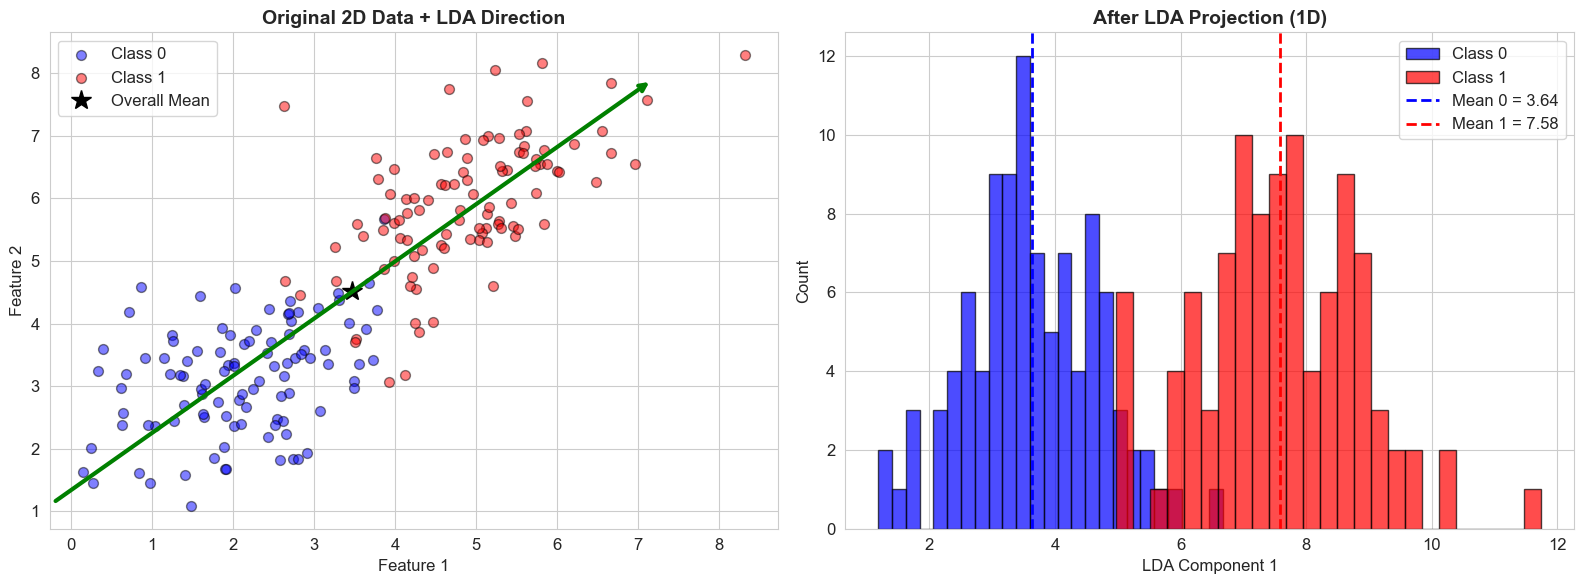

📊 Separation of projected means: 3.9398
📊 Class 0 std: 1.0440, Class 1 std: 1.2635
→ Large mean separation + small within-class spread = great discriminability!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Original 2D data with LDA direction arrow
w_dir = lda_scratch.eigenvectors_[:, 0]
w_dir = w_dir / np.linalg.norm(w_dir)
om = lda_scratch.overall_mean_

axes[0].scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
               c='blue', alpha=0.5, s=50, edgecolors='k', label='Class 0')
axes[0].scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
               c='red', alpha=0.5, s=50, edgecolors='k', label='Class 1')

# Draw the LDA projection direction
axes[0].annotate('', xy=om + w_dir * 5, xytext=om - w_dir * 5,
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
axes[0].plot(*om, 'k*', markersize=15, label='Overall Mean')
axes[0].set_title('Original 2D Data + LDA Direction', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

# Right: Projected 1D histogram
proj_0 = X_projected[y_demo == 0].flatten()
proj_1 = X_projected[y_demo == 1].flatten()

axes[1].hist(proj_0, bins=25, alpha=0.7, color='blue', label='Class 0', edgecolor='black')
axes[1].hist(proj_1, bins=25, alpha=0.7, color='red', label='Class 1', edgecolor='black')
axes[1].axvline(x=proj_0.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean 0 = {proj_0.mean():.2f}')
axes[1].axvline(x=proj_1.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean 1 = {proj_1.mean():.2f}')
axes[1].set_title('After LDA Projection (1D)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LDA Component 1')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"📊 Separation of projected means: {abs(proj_1.mean() - proj_0.mean()):.4f}")
print(f"📊 Class 0 std: {proj_0.std():.4f}, Class 1 std: {proj_1.std():.4f}")
print("→ Large mean separation + small within-class spread = great discriminability!")

## 8. Real-Life Example 1 — Customer Segmentation

---

**Scenario:** A retail company has data on customers with features like age, annual income, spending score, and loyalty years. They want to understand which features best discriminate between 3 customer segments (Budget, Regular, Premium).

LDA helps identify the most discriminating feature combinations and reduces the data to visualize clusters.

📋 Customer Dataset Sample:
         age  annual_income  spending_score  loyalty_years segment
0  27.483571   32003.942803       27.565075       0.949857  Budget
1  24.308678   32771.585676       31.597284       1.764114  Budget
2  28.238443   24559.802227       51.209404       0.211419  Budget
3  32.615149   31858.029577       49.155554       1.403237  Budget
4  23.829233   32344.579786       39.686476       0.575794  Budget
5  23.829315   24285.188656       41.759911       0.365702  Budget
6  32.896064   44926.196089       59.164973       0.914376  Budget
7  28.837174   33790.663367       31.126429       0.171806  Budget
8  22.652628   20469.572022       48.206461       0.557081  Budget
9  27.712800   35252.428869       36.967110       0.041698  Budget

Shape: (450, 5)

Segment distribution:
segment
Budget     150
Regular    150
Premium    150
Name: count, dtype: int64


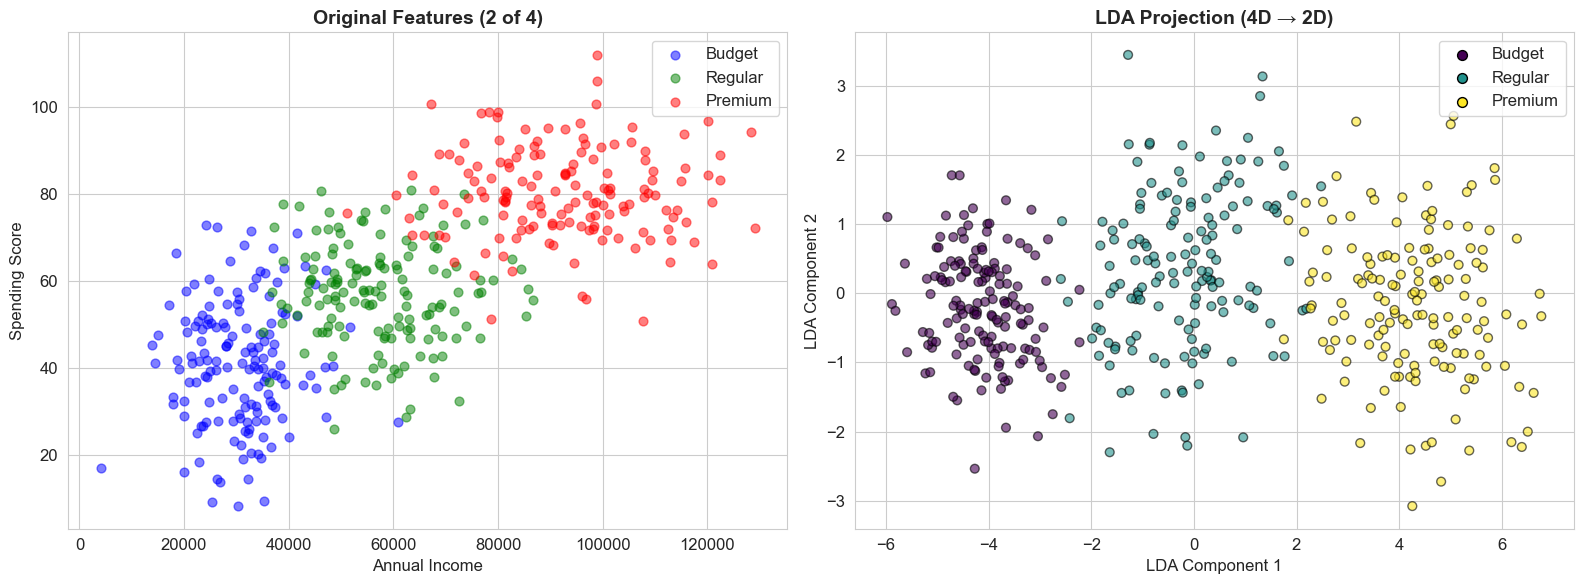


📊 LDA Coefficients (feature importance for discrimination):
                   age  annual_income  spending_score  loyalty_years
Budget vs rest  -3.661         -5.685          -2.704         -4.318
Regular vs rest  0.432         -0.546          -0.343         -0.351
Premium vs rest  3.228          6.230           3.047          4.669

→ Higher absolute coefficient = feature is more important for separating that class


In [ ]:
# Create a realistic customer segmentation dataset
np.random.seed(42)
n_per_segment = 150

# Segment 0: Budget customers — younger, lower income, moderate spending
budget = pd.DataFrame({
    'age': np.random.normal(25, 5, n_per_segment),
    'annual_income': np.random.normal(30000, 8000, n_per_segment),
    'spending_score': np.random.normal(40, 15, n_per_segment),
    'loyalty_years': np.random.normal(1, 0.8, n_per_segment),
    'segment': 'Budget'
})

# Segment 1: Regular customers — middle-aged, moderate income
regular = pd.DataFrame({
    'age': np.random.normal(40, 8, n_per_segment),
    'annual_income': np.random.normal(55000, 12000, n_per_segment),
    'spending_score': np.random.normal(55, 12, n_per_segment),
    'loyalty_years': np.random.normal(4, 2, n_per_segment),
    'segment': 'Regular'
})

# Segment 2: Premium customers — older, high income, high spending
premium = pd.DataFrame({
    'age': np.random.normal(50, 7, n_per_segment),
    'annual_income': np.random.normal(90000, 15000, n_per_segment),
    'spending_score': np.random.normal(80, 10, n_per_segment),
    'loyalty_years': np.random.normal(8, 2, n_per_segment),
    'segment': 'Premium'
})

customers = pd.concat([budget, regular, premium], ignore_index=True)
customers['loyalty_years'] = customers['loyalty_years'].clip(lower=0)

print("📋 Customer Dataset Sample:")
print(customers.head(10))
print(f"\nShape: {customers.shape}")
print(f"\nSegment distribution:\n{customers['segment'].value_counts()}")

# Prepare features
features = ['age', 'annual_income', 'spending_score', 'loyalty_years']
X_cust = customers[features].values
y_cust = customers['segment'].map({'Budget': 0, 'Regular': 1, 'Premium': 2}).values

# Standardize
scaler = StandardScaler()
X_cust_scaled = scaler.fit_transform(X_cust)

# Apply LDA (3 classes → max 2 components)
lda_cust = LinearDiscriminantAnalysis(n_components=2)
X_cust_lda = lda_cust.fit_transform(X_cust_scaled, y_cust)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original: 2 most correlated features
axes[0].scatter(X_cust[y_cust == 0, 1], X_cust[y_cust == 0, 2], c='blue', alpha=0.5, s=40, label='Budget')
axes[0].scatter(X_cust[y_cust == 1, 1], X_cust[y_cust == 1, 2], c='green', alpha=0.5, s=40, label='Regular')
axes[0].scatter(X_cust[y_cust == 2, 1], X_cust[y_cust == 2, 2], c='red', alpha=0.5, s=40, label='Premium')
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Original Features (2 of 4)', fontsize=14, fontweight='bold')
axes[0].legend()

# LDA-projected
scatter = axes[1].scatter(X_cust_lda[:, 0], X_cust_lda[:, 1], c=y_cust,
                          cmap='viridis', alpha=0.6, s=40, edgecolors='k')
axes[1].set_xlabel('LDA Component 1')
axes[1].set_ylabel('LDA Component 2')
axes[1].set_title('LDA Projection (4D → 2D)', fontsize=14, fontweight='bold')
legend_labels = ['Budget', 'Regular', 'Premium']
handles = [plt.scatter([], [], c=plt.cm.viridis(i / 2), s=50, edgecolors='k') for i in range(3)]
axes[1].legend(handles, legend_labels)

plt.tight_layout()
plt.show()

# Interpret LDA coefficients
print("\n📊 LDA Coefficients (feature importance for discrimination):")
coef_df = pd.DataFrame(lda_cust.coef_, columns=features,
                       index=['Budget vs rest', 'Regular vs rest', 'Premium vs rest'])
print(coef_df.round(3))
print("\n→ Higher absolute coefficient = feature is more important for separating that class")

## 9. Real-Life Example 2 — Medical Diagnosis (Breast Cancer Dataset)

---


**Scenario:** Doctors need to classify tumors as **Malignant** or **Benign** based on 30 cell measurements (radius, texture, perimeter, area, smoothness, etc.). With 30 features, it's hard to visualize or interpret. LDA reduces these 30 features to **1 single component** that best discriminates between the two diagnoses.

> This is exactly how LDA aids **interpretability in healthcare** — instead of 30 confusing numbers, give the doctor **one score** that captures the most discriminative information.

In [ ]:
# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target
feature_names_cancer = cancer.feature_names

In [ ]:
c_data_pd = pd.DataFrame(X_cancer, columns=feature_names_cancer)
c_data_pd['target'] = y_cancer
c_data_pd.shape

(569, 31)

In [ ]:
c_data_pd.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
c_data_pd.target.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [ ]:
print(f"Dataset: {cancer.DESCR[:200]}...")
print(f"\nShape: {X_cancer.shape} → {X_cancer.shape[1]} features!")
print(f"Classes: {cancer.target_names} → {np.bincount(y_cancer)}")

Dataset: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: ...

Shape: (569, 30) → 30 features!
Classes: ['malignant' 'benign'] → [212 357]


In [ ]:
# Train-test split FIRST (avoid data leakage)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer)

In [ ]:
X_train_c.shape, X_test_c.shape

((398, 30), (171, 30))

In [ ]:
# Standardize — fit on training data only, transform both
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [ ]:
pd.DataFrame(X_train_c_scaled, columns=feature_names_cancer).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.709821,-0.258417,-0.637396,-0.711996,1.628430,0.847289,0.166501,0.196420,0.542716,1.347151,...,-0.600068,-0.065867,-0.565662,-0.622613,2.019222,0.186202,0.180187,0.400933,-0.414074,0.445223
1,-0.830331,2.231127,-0.874980,-0.779081,-1.597569,-1.267717,-1.086471,-1.243232,-2.658543,-1.052699,...,-0.897361,1.975153,-0.949574,-0.779331,-1.747652,-1.229372,-1.258947,-1.692788,-2.095723,-1.323417
2,-1.011097,-0.227270,-1.035172,-0.911780,-1.077779,-1.098096,-0.841650,-0.955767,2.023790,-0.688547,...,-1.099685,-0.396544,-1.122706,-0.909132,-1.515009,-1.165663,-1.078897,-1.364240,-0.354125,-0.886645
3,-0.382721,-0.111581,-0.408966,-0.453660,0.072810,-0.443255,-0.756276,-0.782409,-0.163916,-0.120413,...,-0.519552,0.027482,-0.575148,-0.531239,-0.108556,-0.445414,-0.692056,-0.463762,-0.284953,-0.622794
4,-0.804508,-1.401961,-0.810071,-0.773196,0.191319,-0.507801,-0.685397,-0.530392,-0.128228,-0.001311,...,-0.814779,-1.524644,-0.858265,-0.747633,0.156312,-0.647239,-0.683022,-0.398999,-0.301862,-0.210724


In [ ]:
# Apply LDA — fit on training data only, transform both
lda_cancer = LinearDiscriminantAnalysis(n_components=1)
X_train_c_scaled_lda = lda_cancer.fit_transform(X_train_c_scaled, y_train_c)
X_test_c_scaled_lda = lda_cancer.transform(X_test_c_scaled)

In [ ]:
X_train_c_scaled_lda.shape, X_test_c_scaled_lda.shape

((398, 1), (171, 1))

In [ ]:
### HOMEWORK: Find the way to get the LDAScore equation (the linear combination of features) from the LDA model

In [ ]:
# Also transform ALL data for the visualization histogram
X_cancer_scaled = scaler_c.transform(X_cancer)
X_cancer_lda = lda_cancer.transform(X_cancer_scaled)

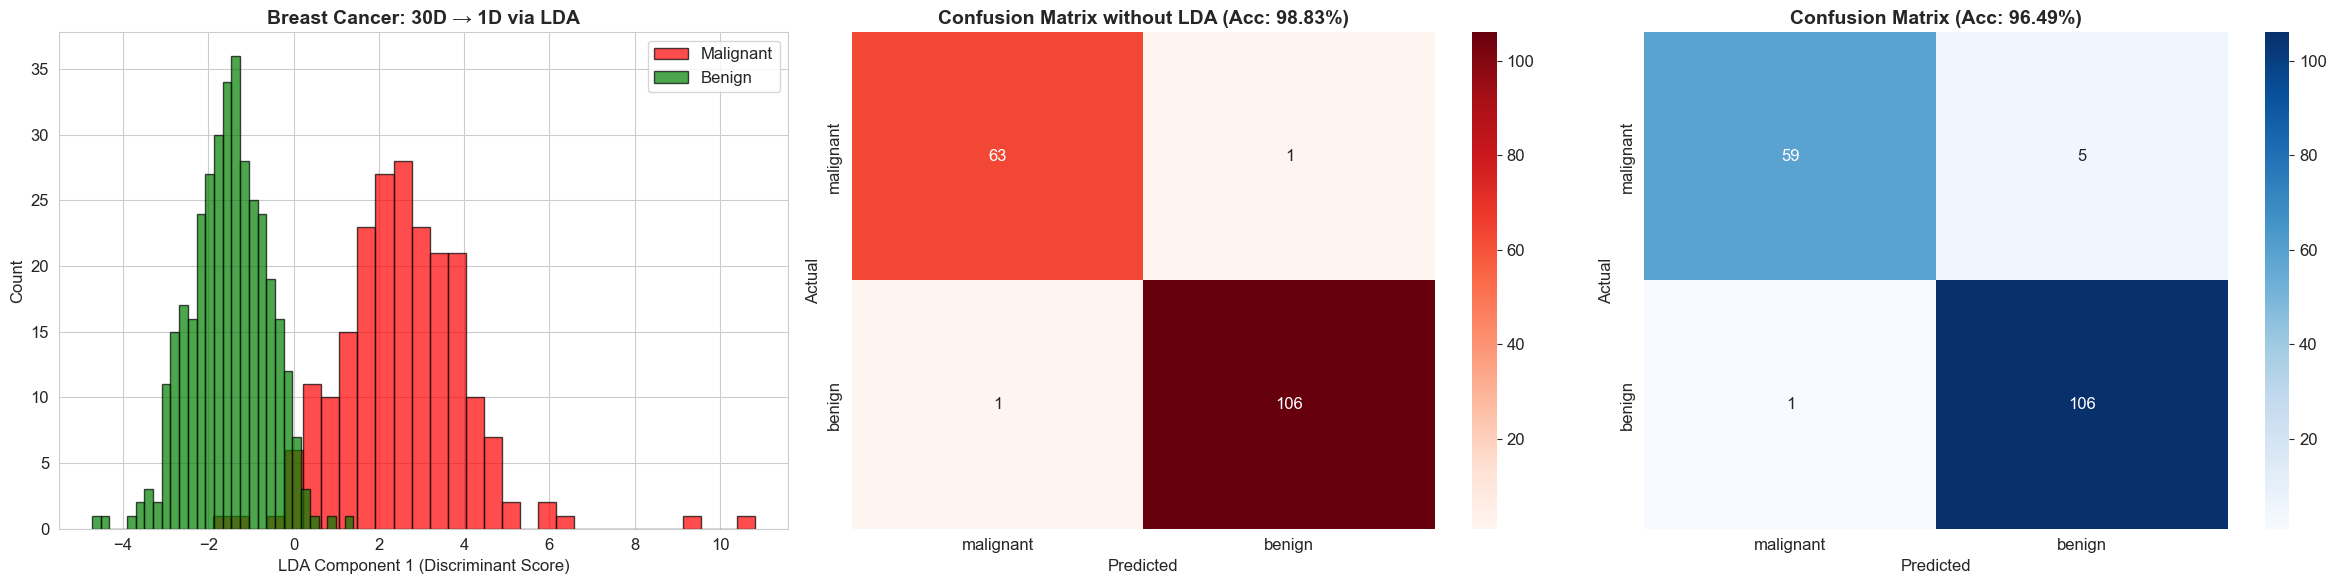

In [ ]:
# Change the figure to have 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# 1D LDA projection as histogram
for label, name, color in [(0, 'Malignant', 'red'), (1, 'Benign', 'green')]:
    mask = y_cancer == label
    axes[0].hist(X_cancer_lda[mask].flatten(), bins=30, alpha=0.7,
                color=color, label=name, edgecolor='black')

axes[0].set_title('Breast Cancer: 30D → 1D via LDA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('LDA Component 1 (Discriminant Score)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=12)


# Classification without LDA
lr_no_lda = LogisticRegression(random_state=42)
lr_no_lda.fit(X_train_c_scaled, y_train_c)
y_pred_no_lda = lr_no_lda.predict(X_test_c_scaled) ## predict function by default gives .5 as the cut-off i.e, any prob > .5 is classified as 1, else 0.
#try using predict_proba and then changing the cut-off to see how it affects the confusion matrix and accuracy.

# Confusion matrix without LDA
cm_no = confusion_matrix(y_test_c, y_pred_no_lda)
sns.heatmap(cm_no, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[1].set_title(f'Confusion Matrix without LDA (Acc: {accuracy_score(y_test_c, y_pred_no_lda):.2%})',
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')


# Classification with LDA
lr_cancer = LogisticRegression(random_state=42)
lr_cancer.fit(X_train_c_scaled_lda, y_train_c)
y_pred_c = lr_cancer.predict(X_test_c_scaled_lda)
# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[2].set_title(f'Confusion Matrix (Acc: {accuracy_score(y_test_c, y_pred_c):.2%})',
                 fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')



plt.tight_layout()
plt.show()

## 10. End-to-End LDA Pipeline Using Scikit-Learn (Wine Dataset)

---


Now let's build a **production-quality ML pipeline** using sklearn on the **Wine dataset** (3 classes, 13 features).

Pipeline steps:
1. Load data → Train/Test split
2. Standardize features
3. Apply LDA for dimensionality reduction (13D → 2D)
4. Train a Logistic Regression classifier
5. Evaluate with accuracy, confusion matrix, and classification report

Wine dataset: 178 samples, 13 features, 3 classes
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

PIPELINE RESULTS: StandardScaler → LDA(2) → LogisticRegression

Accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



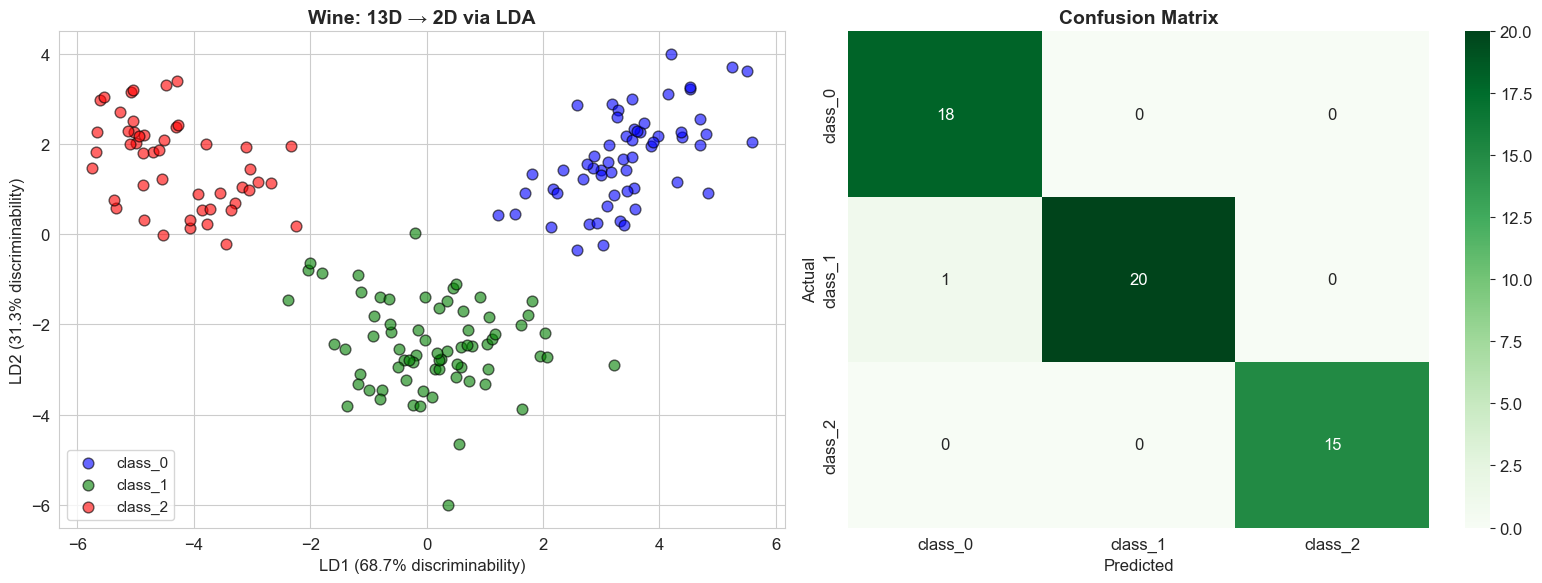


✅ Reduced 13 features → 2 LDA components, yet achieved 98.15% accuracy!


In [ ]:
# Load Wine dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
print(f"Wine dataset: {X_wine.shape[0]} samples, {X_wine.shape[1]} features, {len(np.unique(y_wine))} classes")
print(f"Feature names: {wine.feature_names}")

# Train-test split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine)

# Build pipeline: StandardScaler → LDA → Logistic Regression
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Fit and predict
pipe_lda.fit(X_train_w, y_train_w)
y_pred_w = pipe_lda.predict(X_test_w)

# Evaluate
print(f"\n{'=' * 60}")
print(f"PIPELINE RESULTS: StandardScaler → LDA(2) → LogisticRegression")
print(f"{'=' * 60}")
print(f"\nAccuracy: {accuracy_score(y_test_w, y_pred_w):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_w, y_pred_w, target_names=wine.target_names))

# Visualize the 2D LDA space
scaler_w = StandardScaler()
X_wine_scaled = scaler_w.fit_transform(X_wine)
lda_wine = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda_wine.fit_transform(X_wine_scaled, y_wine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LDA 2D scatter
colors = ['blue', 'green', 'red']
for i, name in enumerate(wine.target_names):
    mask = y_wine == i
    axes[0].scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1],
                   c=colors[i], alpha=0.6, s=60, edgecolors='k', label=name)
axes[0].set_title('Wine: 13D → 2D via LDA', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'LD1 ({lda_wine.explained_variance_ratio_[0]:.1%} discriminability)')
axes[0].set_ylabel(f'LD2 ({lda_wine.explained_variance_ratio_[1]:.1%} discriminability)')
axes[0].legend(fontsize=11)

# Confusion matrix
cm_w = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\n✅ Reduced 13 features → 2 LDA components, yet achieved {accuracy_score(y_test_w, y_pred_w):.2%} accuracy!")

## 11. LDA vs PCA — Head-to-Head Comparison

---

| Aspect | PCA | LDA |
|--------|-----|-----|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Uses labels?** | No | Yes |
| **Max components** | min(N, d) | min(C-1, d) |
| **Best for** | General dimensionality reduction | Classification tasks |

Let's compare them on the same Wine dataset:

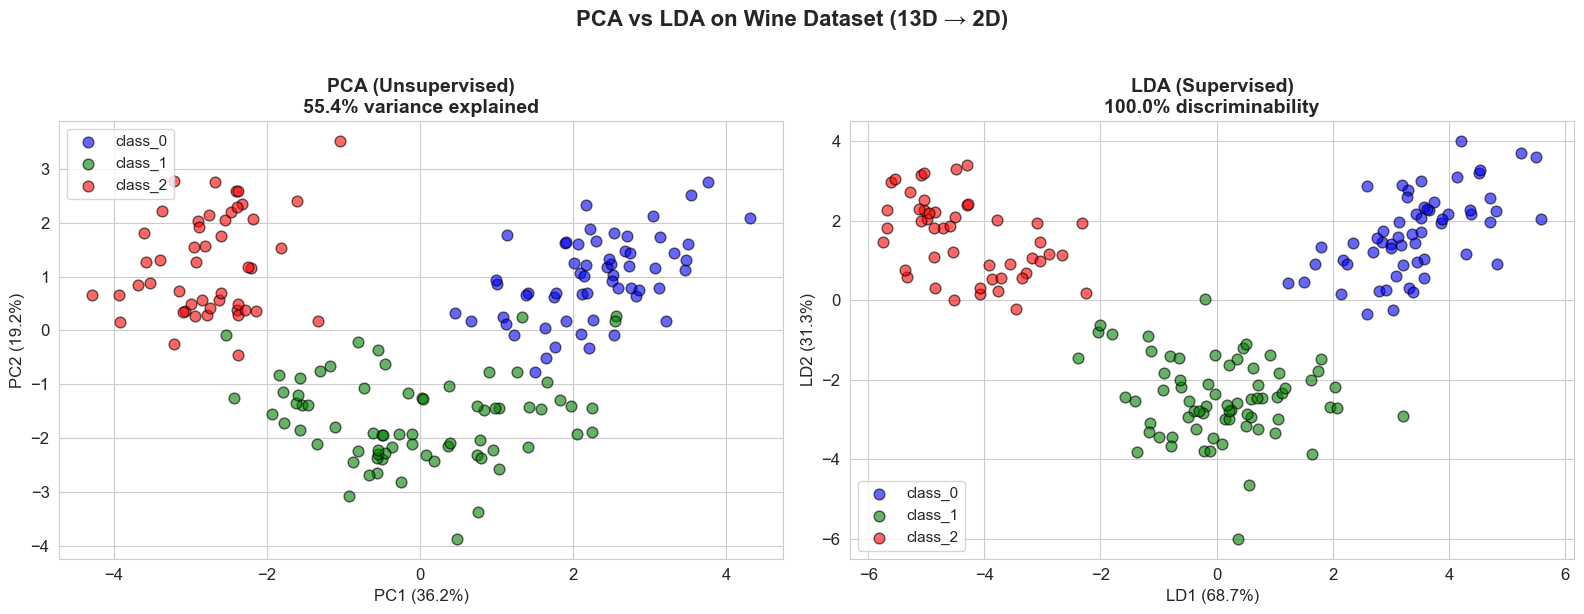


📊 Classification Accuracy Comparison:
                    Method  Accuracy  Features Used
        PCA (2 components)  0.944444              2
        LDA (2 components)  0.981481              2
No reduction (13 features)  0.981481             13

→ LDA achieves better or comparable accuracy with FAR fewer features!


In [ ]:
# PCA on Wine dataset (same 2 components for comparison)
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for i, name in enumerate(wine.target_names):
    mask = y_wine == i
    axes[0].scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
                   c=colors[i], alpha=0.6, s=60, edgecolors='k', label=name)
axes[0].set_title(f'PCA (Unsupervised)\n{pca_wine.explained_variance_ratio_.sum():.1%} variance explained',
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=11)

# LDA scatter (already computed)
for i, name in enumerate(wine.target_names):
    mask = y_wine == i
    axes[1].scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1],
                   c=colors[i], alpha=0.6, s=60, edgecolors='k', label=name)
axes[1].set_title(f'LDA (Supervised)\n{lda_wine.explained_variance_ratio_.sum():.1%} discriminability',
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'LD1 ({lda_wine.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'LD2 ({lda_wine.explained_variance_ratio_[1]:.1%})')
axes[1].legend(fontsize=11)

plt.suptitle('PCA vs LDA on Wine Dataset (13D → 2D)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Classification accuracy comparison
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])
pipe_pca.fit(X_train_w, y_train_w)
y_pred_pca = pipe_pca.predict(X_test_w)

comparison = pd.DataFrame({
    'Method': ['PCA (2 components)', 'LDA (2 components)', 'No reduction (13 features)'],
    'Accuracy': [
        accuracy_score(y_test_w, y_pred_pca),
        accuracy_score(y_test_w, y_pred_w),
        LogisticRegression(random_state=42, max_iter=1000).fit(
            StandardScaler().fit_transform(X_train_w), y_train_w).score(
            StandardScaler().fit(X_train_w).transform(X_test_w), y_test_w)
    ],
    'Features Used': [2, 2, 13]
})
print("\n📊 Classification Accuracy Comparison:")
print(comparison.to_string(index=False))
print("\n→ LDA achieves better or comparable accuracy with FAR fewer features!")

## 12. What Happens WITHOUT LDA? — The Curse of Dimensionality

---


This is the **most important section** for understanding WHY LDA matters.

We'll create a **high-dimensional dataset** with many irrelevant/noisy features and show:
- Classifiers struggle with raw high-dimensional data
- Training takes longer
- Overfitting becomes a serious problem
- LDA rescues us by extracting only the discriminative information

In [ ]:
# Create a high-dimensional dataset with many noisy features
np.random.seed(42)

# 5 classes, 50 features (only ~5 are informative, rest are noise!)
X_hd, y_hd = make_classification(
    n_samples=1000, n_features=50, n_informative=5, n_redundant=5,
    n_classes=5, n_clusters_per_class=1, class_sep=1.0,
    random_state=42
)

print(f"High-dimensional dataset: {X_hd.shape}")
print(f"Classes: {np.unique(y_hd)} ({np.bincount(y_hd)})")
print(f"Only 5 of 50 features are truly informative!")

X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X_hd, y_hd, test_size=0.3, random_state=42, stratify=y_hd)

# Standardize
scaler_hd = StandardScaler()
X_train_hd_s = scaler_hd.fit_transform(X_train_hd)
X_test_hd_s = scaler_hd.transform(X_test_hd)

# --- WITHOUT LDA: Train classifiers on all 50 features ---
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results_no_lda = []
print(f"\n{'=' * 70}")
print("WITHOUT LDA — Training on all 50 features")
print(f"{'=' * 70}")

for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train_hd_s, y_train_hd)
    train_time = time.time() - start

    train_acc = clf.score(X_train_hd_s, y_train_hd)
    test_acc = clf.score(X_test_hd_s, y_test_hd)
    y_pred_hd = clf.predict(X_test_hd_s)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_hd, y_pred_hd, average='weighted')

    results_no_lda.append({
        'Classifier': name, 'LDA': 'No', 'Features': 50,
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'Precision': prec, 'Recall': rec, 'F1': f1,
        'Time (s)': train_time
    })
    gap = train_acc - test_acc
    overfit = "⚠️ OVERFITTING!" if gap > 0.1 else "✅ OK"
    print(f"  {name:25s} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f} {overfit} | Time: {train_time:.4f}s")

High-dimensional dataset: (1000, 50)
Classes: [0 1 2 3 4] ([199 200 201 199 201])
Only 5 of 50 features are truly informative!

WITHOUT LDA — Training on all 50 features
  Logistic Regression       | Train: 0.807 | Test: 0.737 | Gap: 0.070 ✅ OK | Time: 0.0163s
  KNN (k=5)                 | Train: 0.727 | Test: 0.580 | Gap: 0.147 ⚠️ OVERFITTING! | Time: 0.0011s
  Decision Tree             | Train: 1.000 | Test: 0.733 | Gap: 0.267 ⚠️ OVERFITTING! | Time: 0.0333s


## 13. WITH LDA — Classification on Reduced Data



Now let's apply LDA first, then train the **same classifiers** on the LDA-reduced features.

In [ ]:
# --- WITH LDA: Reduce 50 features to 4 components (5 classes → max 4 components) ---
lda_hd = LinearDiscriminantAnalysis(n_components=4)
X_train_lda = lda_hd.fit_transform(X_train_hd_s, y_train_hd)
X_test_lda = lda_hd.transform(X_test_hd_s)

print(f"LDA reduced: {X_train_hd_s.shape[1]} features → {X_train_lda.shape[1]} components")
print(f"Explained variance ratio: {lda_hd.explained_variance_ratio_}")
print(f"Total discriminability captured: {lda_hd.explained_variance_ratio_.sum():.1%}")

results_with_lda = []
print(f"\n{'=' * 70}")
print(f"WITH LDA — Training on {X_train_lda.shape[1]} LDA components (from 50 features)")
print(f"{'=' * 70}")

classifiers_lda = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, clf in classifiers_lda.items():
    start = time.time()
    clf.fit(X_train_lda, y_train_hd)
    train_time = time.time() - start

    train_acc = clf.score(X_train_lda, y_train_hd)
    test_acc = clf.score(X_test_lda, y_test_hd)
    y_pred_lda = clf.predict(X_test_lda)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_hd, y_pred_lda, average='weighted')

    results_with_lda.append({
        'Classifier': name, 'LDA': 'Yes', 'Features': 4,
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'Precision': prec, 'Recall': rec, 'F1': f1,
        'Time (s)': train_time
    })
    gap = train_acc - test_acc
    overfit = "⚠️ OVERFITTING!" if gap > 0.1 else "✅ OK"
    print(f"  {name:25s} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f} {overfit} | Time: {train_time:.4f}s")

LDA reduced: 50 features → 4 components
Explained variance ratio: [0.53184714 0.28415646 0.13605548 0.04794092]
Total discriminability captured: 100.0%

WITH LDA — Training on 4 LDA components (from 50 features)
  Logistic Regression       | Train: 0.769 | Test: 0.757 | Gap: 0.012 ✅ OK | Time: 0.0000s
  KNN (k=5)                 | Train: 0.833 | Test: 0.767 | Gap: 0.066 ✅ OK | Time: 0.0159s
  Decision Tree             | Train: 1.000 | Test: 0.697 | Gap: 0.303 ⚠️ OVERFITTING! | Time: 0.0043s


## 14. Performance Comparison — With vs Without LDA (The Big Picture)

📊 COMPREHENSIVE COMPARISON: With vs Without LDA
         Classifier LDA  Features  Test Acc  Precision       F1  Time (s)
Logistic Regression  No        50  0.736667   0.736494 0.735881  0.016257
          KNN (k=5)  No        50  0.580000   0.597738 0.578889  0.001100
      Decision Tree  No        50  0.733333   0.732621 0.732015  0.033267
Logistic Regression Yes         4  0.756667   0.760165 0.757509  0.000000
          KNN (k=5) Yes         4  0.766667   0.769683 0.766779  0.015900
      Decision Tree Yes         4  0.696667   0.695281 0.694332  0.004312


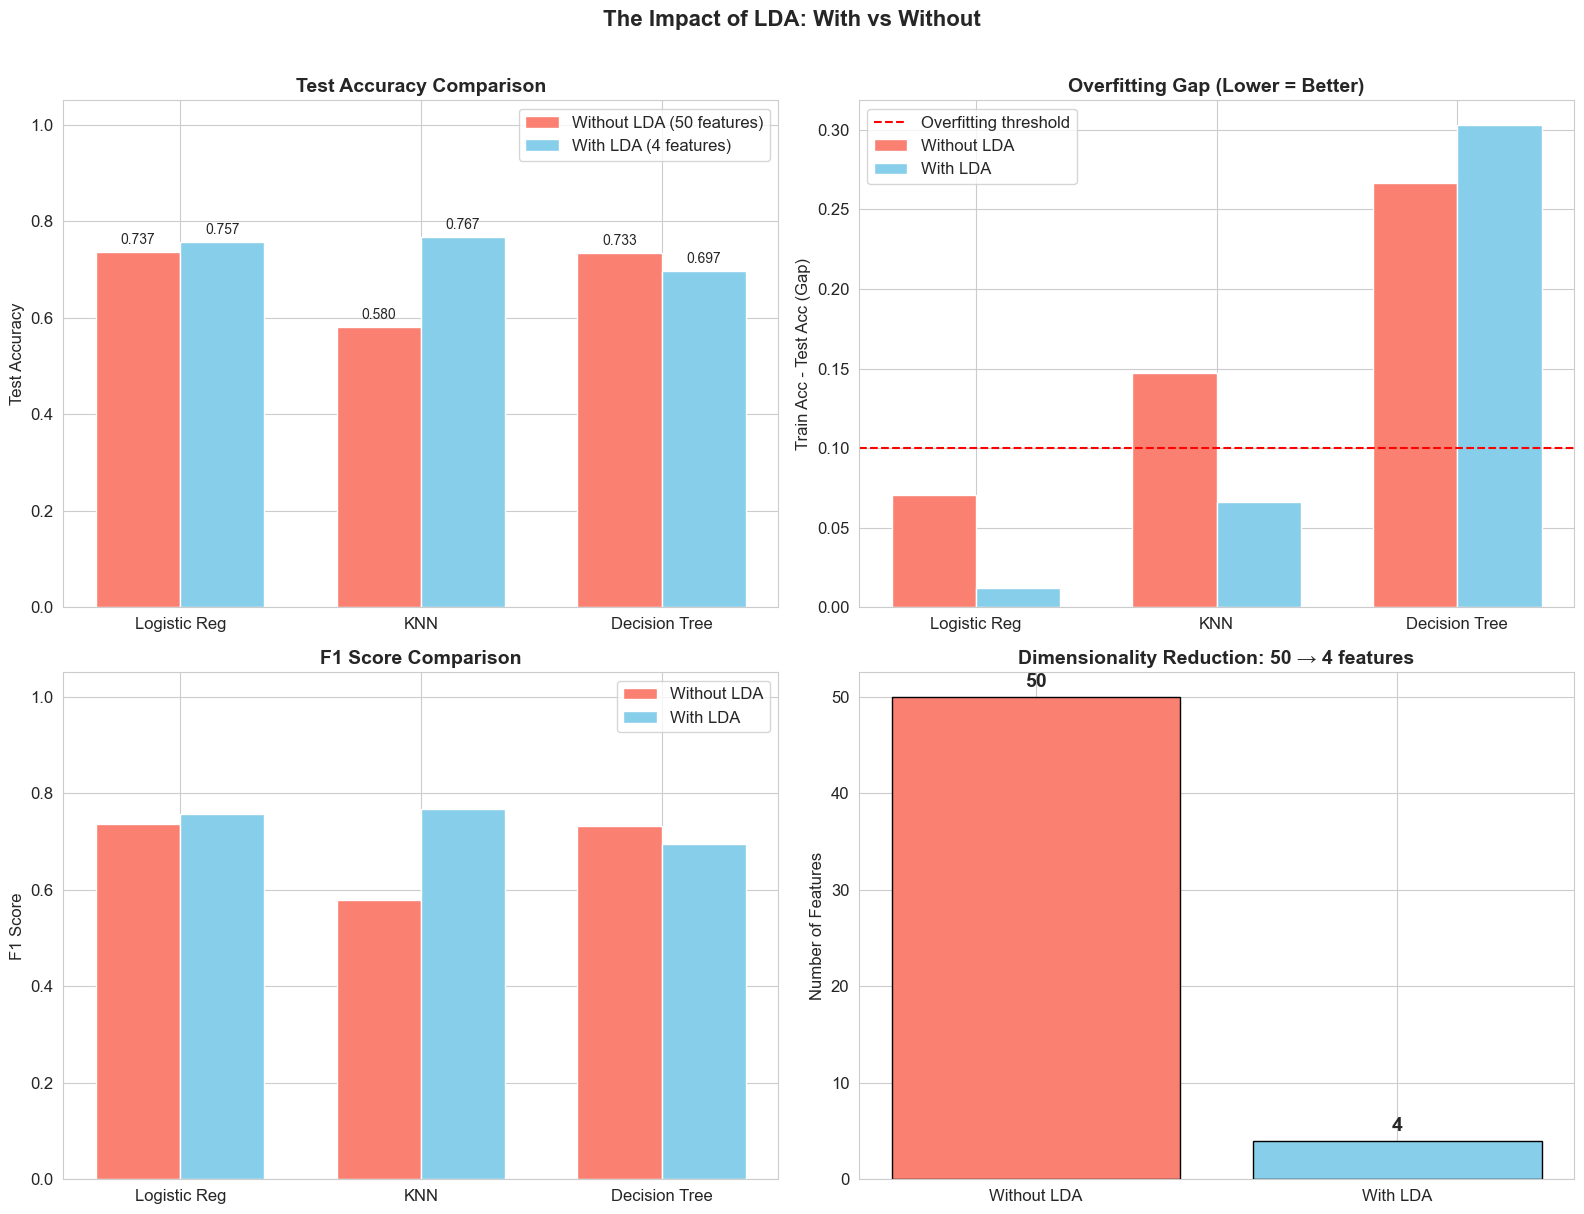


🎯 KEY TAKEAWAYS:
  1. LDA reduces 50 features to just 4, making models simpler and faster
  2. LDA reduces overfitting (especially for Decision Trees)
  3. LDA often maintains or improves accuracy by removing noise
  4. KNN benefits hugely from LDA (curse of dimensionality!)


In [ ]:
# Combine results into a DataFrame
all_results = pd.DataFrame(results_no_lda + results_with_lda)

print("📊 COMPREHENSIVE COMPARISON: With vs Without LDA")
print("=" * 90)
print(all_results[['Classifier', 'LDA', 'Features', 'Test Acc', 'Precision', 'F1', 'Time (s)']].to_string(index=False))
print("=" * 90)

# Create comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test Accuracy
x = np.arange(3)
width = 0.35
no_lda_acc = all_results[all_results['LDA'] == 'No']['Test Acc'].values
with_lda_acc = all_results[all_results['LDA'] == 'Yes']['Test Acc'].values
clf_names = ['Logistic Reg', 'KNN', 'Decision Tree']

bars1 = axes[0, 0].bar(x - width/2, no_lda_acc, width, label='Without LDA (50 features)', color='salmon')
bars2 = axes[0, 0].bar(x + width/2, with_lda_acc, width, label='With LDA (4 features)', color='skyblue')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(clf_names)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.05)
for bar in bars1:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

# 2. Overfitting gap (Train - Test accuracy)
no_lda_gap = (all_results[all_results['LDA'] == 'No']['Train Acc'].values -
              all_results[all_results['LDA'] == 'No']['Test Acc'].values)
with_lda_gap = (all_results[all_results['LDA'] == 'Yes']['Train Acc'].values -
                all_results[all_results['LDA'] == 'Yes']['Test Acc'].values)

axes[0, 1].bar(x - width/2, no_lda_gap, width, label='Without LDA', color='salmon')
axes[0, 1].bar(x + width/2, with_lda_gap, width, label='With LDA', color='skyblue')
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', label='Overfitting threshold')
axes[0, 1].set_ylabel('Train Acc - Test Acc (Gap)')
axes[0, 1].set_title('Overfitting Gap (Lower = Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(clf_names)
axes[0, 1].legend()

# 3. F1 Score
no_lda_f1 = all_results[all_results['LDA'] == 'No']['F1'].values
with_lda_f1 = all_results[all_results['LDA'] == 'Yes']['F1'].values

axes[1, 0].bar(x - width/2, no_lda_f1, width, label='Without LDA', color='salmon')
axes[1, 0].bar(x + width/2, with_lda_f1, width, label='With LDA', color='skyblue')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(clf_names)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.05)

# 4. Feature reduction visualization
axes[1, 1].bar(['Without LDA', 'With LDA'], [50, 4], color=['salmon', 'skyblue'], edgecolor='black')
axes[1, 1].set_ylabel('Number of Features')
axes[1, 1].set_title('Dimensionality Reduction: 50 → 4 features', fontsize=14, fontweight='bold')
for i, v in enumerate([50, 4]):
    axes[1, 1].text(i, v + 1, str(v), ha='center', fontsize=14, fontweight='bold')

plt.suptitle('The Impact of LDA: With vs Without', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n🎯 KEY TAKEAWAYS:")
print("  1. LDA reduces 50 features to just 4, making models simpler and faster")
print("  2. LDA reduces overfitting (especially for Decision Trees)")
print("  3. LDA often maintains or improves accuracy by removing noise")
print("  4. KNN benefits hugely from LDA (curse of dimensionality!)")

## 15. When Does LDA Fail? — Assumptions, Limitations & Explanations

---

Before using LDA, you need to know its **assumptions** — the conditions it expects your data to satisfy. If these are badly violated, LDA can give poor results. Let's go through each one with simple explanations.

---

### Assumption 1: Features Follow a Normal (Bell-Curve) Distribution Within Each Class

**What does "normally distributed" mean?**

Imagine measuring the heights of all boys in a class. Most boys are around average height, a few are very tall, a few are very short. If you plot a histogram, it looks like a **bell curve** (tall in the middle, tapering on both sides). This is a **normal distribution** (also called **Gaussian distribution**).

LDA assumes that **within each class**, the features follow this bell-curve shape.

**Why does LDA need this?**
Because the math behind LDA (scatter matrices, eigenvalues) is derived assuming Gaussian data. If data is heavily skewed (lopsided) or has multiple peaks, the scatter matrices don't accurately capture the "shape" of each class.

**How to check:** Use a **QQ Plot** (Quantile-Quantile Plot):
- Plot your data's values against what a perfect normal distribution would look like
- If the dots fall roughly on the straight diagonal line → data is approximately normal
- If dots curve away from the line → data is NOT normal

---

### Assumption 2: Equal Covariance Matrices Across Classes (Homoscedasticity)

**What is "covariance"?**

Think of covariance as a measure of **how two features move together**:
- If tall people tend to be heavier → height and weight have **positive covariance**
- If older cars tend to be cheaper → age and price have **negative covariance**
- If shoe size and IQ have no relationship → **near-zero covariance**

**What is a "covariance matrix"?**

When you have multiple features (say height, weight, age), the **covariance matrix** is a table that stores the covariance between **every pair** of features. It describes the **shape and spread** of your data cloud — is it round? elongated? tilted?

**What is "homoscedasticity" (homo-ske-das-TIS-ity)?**

Just a fancy word meaning **"equal spread."** LDA assumes all classes have the **same covariance matrix** — i.e., each class's data cloud has the **same shape**, just centered at different locations.

Example of violation:
- Class A: students with very similar heights and weights (tight, small cluster)
- Class B: students with wildly varying heights and weights (big, spread-out cluster)
- These have **unequal covariances** → LDA's assumption is violated

**What is "Frobenius norm"?** (seen in the code below)

It's just a way to summarize an entire matrix as a **single number** — think of it as the matrix's "overall size." We use it to quickly compare whether two covariance matrices are similar in magnitude.

**Why does LDA need equal covariance?**

LDA computes a single **shared** within-class scatter matrix $S_W$ by adding up scatter from all classes. If one class is very spread out and another is very tight, this shared matrix is a poor average, and the LDA projection direction will be wrong.

**Fix:** Use **QDA (Quadratic Discriminant Analysis)** — it allows each class to have its **own** covariance matrix and draws curved (quadratic) boundaries instead of straight lines.

---

### Assumption 3: $S_W$ Must Be Invertible (No Singular Matrix)

**What is "matrix inverse"?**

Just like the inverse of 5 is $\frac{1}{5}$, matrices also have inverses. The inverse of matrix $A$ is written $A^{-1}$, and it "undoes" the effect of $A$:  $A \times A^{-1} = I$ (the identity matrix, like multiplying by 1).

**What is a "singular" matrix?**

A matrix that **cannot be inverted** — like trying to compute $\frac{1}{0}$. It happens when:
- You have **more features than samples** ($d > N$). Example: 50 features but only 30 data points.
- Some features are **exact copies** or **perfectly correlated** with others.

In both cases, the matrix doesn't have "enough information" in all directions to be invertible.

**Why does LDA need $S_W$ to be invertible?**

The LDA solution is $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$. If $S_W$ is singular, $S_W^{-1}$ doesn't exist, and LDA literally cannot compute the answer!

**Fixes:**
- **Regularized LDA** — adds a small value $\epsilon$ to the diagonal of $S_W$: $(S_W + \epsilon I)^{-1}$. This is like adding a tiny number to avoid dividing by zero.
- **PCA first, then LDA** — use PCA to reduce dimensions to fewer than $N$ samples, then apply LDA on the reduced data.

---

### Failure Case: Non-Linear Class Boundaries

**What is a "linear boundary"?**

A **straight line** (in 2D), a **flat plane** (in 3D), or a **hyperplane** (in higher dimensions) that separates two classes. Think of a wall or a fence dividing two groups — if the wall is flat, it's linear.

LDA can **ONLY** draw these straight/flat boundaries.

**What are "non-linear boundaries"?**

Sometimes classes are arranged in **curves, circles, or spirals**. No straight line can separate them:
- Two **crescent moons** interleaved (the `make_moons` dataset below)
- One class forming a **ring** around another (concentric circles)
- Two **spirals** winding around each other

LDA tries to fit a straight line through curved data → **it fails badly**.

**Alternatives when data is non-linear:**
| Method | How it helps |
|--------|-------------|
| **Kernel LDA** | Projects data into a higher-dimensional space where a straight line CAN separate the classes (similar idea to Kernel SVM) |
| **SVM (RBF kernel)** | Draws flexible curved boundaries |
| **Random Forest / Neural Networks** | Learn arbitrary complex boundaries |
| **QDA** | Draws quadratic (curved) boundaries — helps if classes have different covariances |

---

### Quick-Reference Summary Table

| Assumption | Plain English | What Happens if Violated | Fix |
|-----------|--------------|-------------------------|-----|
| **Normality** | Data in each class follows a bell curve | Scatter matrices are inaccurate | Transform features (log, Box-Cox) or use robust methods |
| **Equal covariance** | All classes have the same "spread shape" | LDA direction is suboptimal | Use **QDA** instead |
| **$S_W$ invertible** | More samples than features ($N > d$) | Can't compute $S_W^{-1}$, LDA crashes | Use **Regularized LDA** or apply PCA first |
| **Linear separability** | A straight line/plane can separate classes | LDA draws a bad boundary, low accuracy | Use **Kernel LDA** or non-linear classifiers |

---

Let's **see** each failure case with code and visuals:

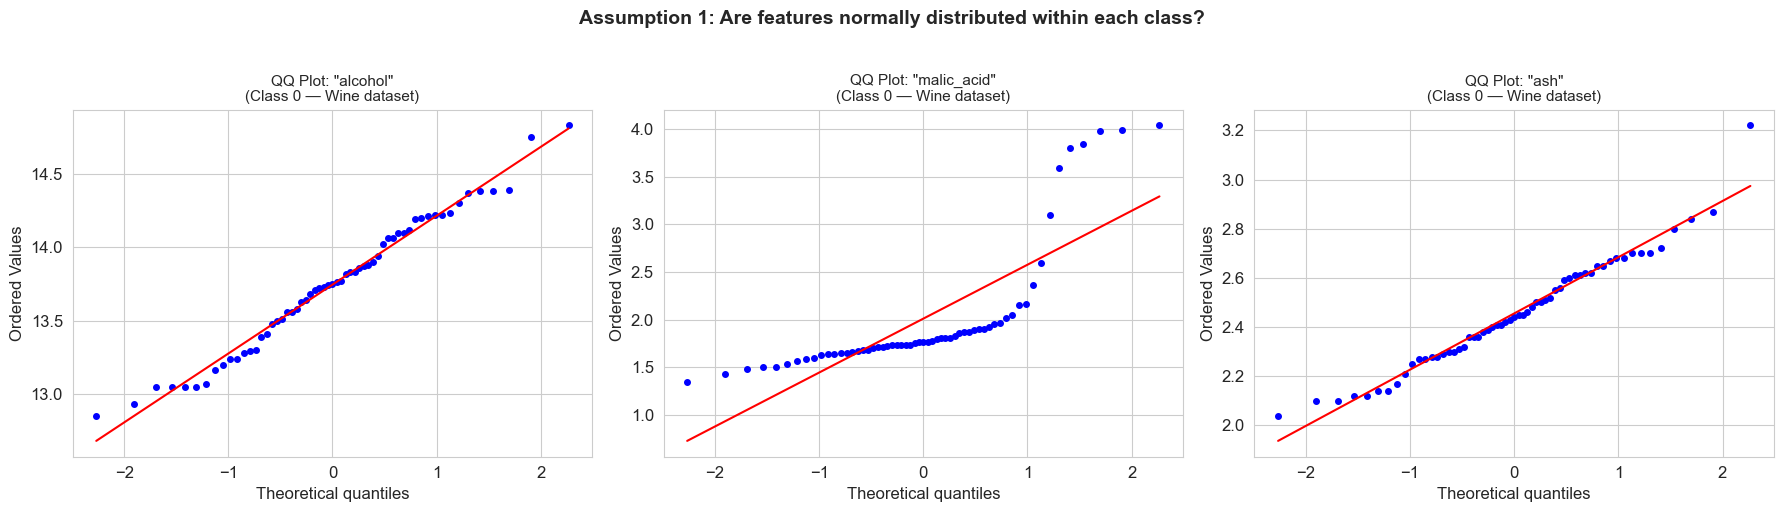

📖 HOW TO READ THESE QQ PLOTS:
   • Dots on the line → Normal distribution ✅ (LDA is happy)
   • Dots curving away → Not normal ❌ (LDA may be inaccurate)
   • Mild deviations are usually OK — LDA is somewhat robust to small violations


In [ ]:
# ============================================================
# FAILURE CASE 1: Checking the NORMALITY assumption
# ============================================================
# We use QQ (Quantile-Quantile) plots to check if data is normal.
# HOW TO READ A QQ PLOT:
#   - If dots follow the diagonal line → data IS approximately normal ✅
#   - If dots curve away from the line → data is NOT normal ❌

from scipy import stats

wine_data = load_wine()
X_w = wine_data.data
y_w = wine_data.target

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    data = X_w[y_w == 0, i]  # Feature i, Class 0 only
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'QQ Plot: "{wine_data.feature_names[i]}"\n(Class 0 — Wine dataset)', fontsize=11)
    ax.get_lines()[0].set_markersize(4)

plt.suptitle('Assumption 1: Are features normally distributed within each class?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📖 HOW TO READ THESE QQ PLOTS:")
print("   • Dots on the line → Normal distribution ✅ (LDA is happy)")
print("   • Dots curving away → Not normal ❌ (LDA may be inaccurate)")
print("   • Mild deviations are usually OK — LDA is somewhat robust to small violations")

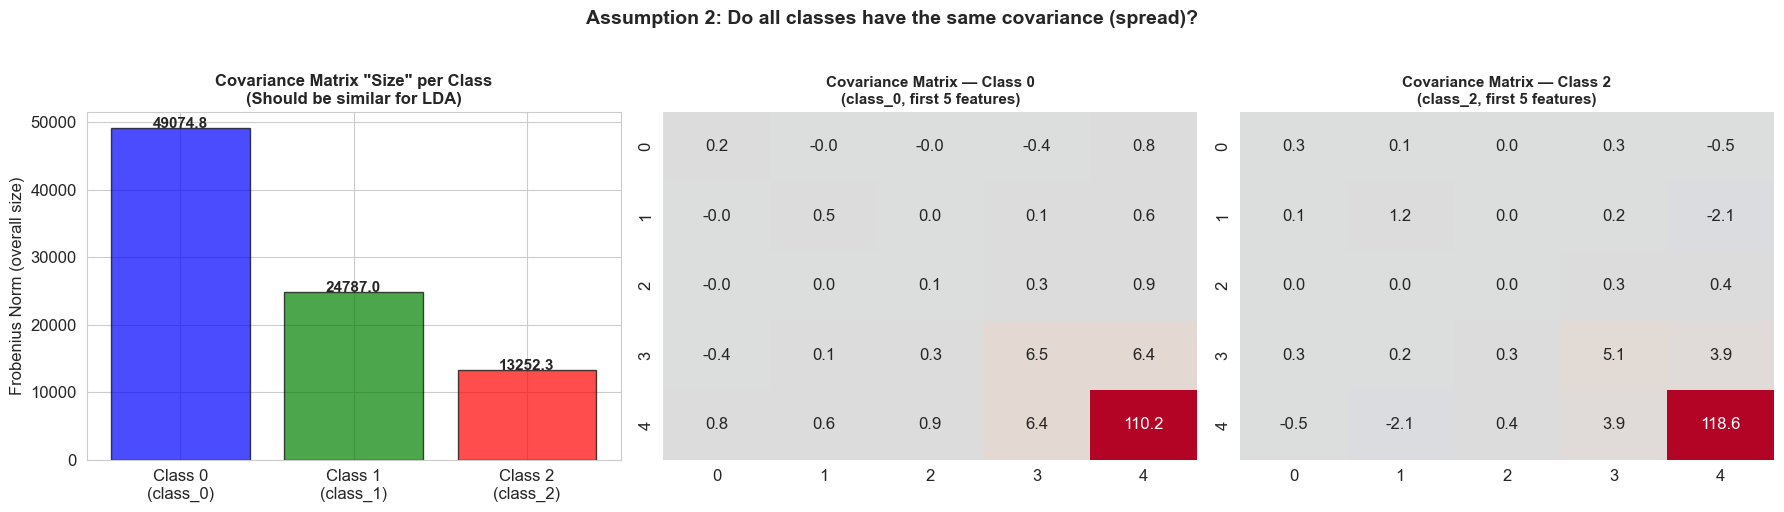

📖 INTERPRETATION:
   Covariance norms: Class 0 = 49074.8, Class 1 = 24787.0, Class 2 = 13252.3
   ⚠️ Ratio of largest/smallest = 3.7 → Quite different! LDA assumption may be violated.
   → Consider using QDA (Quadratic Discriminant Analysis) instead


In [ ]:
# ============================================================
# FAILURE CASE 2: Checking the EQUAL COVARIANCE assumption
# ============================================================
# We compute the covariance matrix for each class and compare their "sizes"
# using the Frobenius norm (just a single number summarizing the whole matrix).
# If all classes have similar norms → assumption is satisfied ✅
# If norms are very different → assumption is violated ❌

cov_matrices = {}
for c in range(3):
    cov_matrices[c] = np.cov(X_w[y_w == c].T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart of covariance matrix "sizes"
cov_norms = [np.linalg.norm(cov_matrices[c], 'fro') for c in range(3)]
bar_colors = ['blue', 'green', 'red']
axes[0].bar([f'Class {c}\n({wine_data.target_names[c]})' for c in range(3)],
           cov_norms, color=bar_colors, edgecolor='black', alpha=0.7)
axes[0].set_title('Covariance Matrix "Size" per Class\n(Should be similar for LDA)',
                 fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frobenius Norm (overall size)')
for i, v in enumerate(cov_norms):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

# Heatmaps of actual covariance matrices for Class 0 and Class 2
# (If they look very different → unequal covariance)
sns.heatmap(cov_matrices[0][:5, :5], ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', cbar=False)
axes[1].set_title(f'Covariance Matrix — Class 0\n({wine_data.target_names[0]}, first 5 features)',
                 fontsize=11, fontweight='bold')

sns.heatmap(cov_matrices[2][:5, :5], ax=axes[2], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', cbar=False)
axes[2].set_title(f'Covariance Matrix — Class 2\n({wine_data.target_names[2]}, first 5 features)',
                 fontsize=11, fontweight='bold')

plt.suptitle('Assumption 2: Do all classes have the same covariance (spread)?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📖 INTERPRETATION:")
print(f"   Covariance norms: Class 0 = {cov_norms[0]:.1f}, Class 1 = {cov_norms[1]:.1f}, Class 2 = {cov_norms[2]:.1f}")
ratio = max(cov_norms) / min(cov_norms)
if ratio > 3:
    print(f"   ⚠️ Ratio of largest/smallest = {ratio:.1f} → Quite different! LDA assumption may be violated.")
    print("   → Consider using QDA (Quadratic Discriminant Analysis) instead")
else:
    print(f"   ✅ Ratio of largest/smallest = {ratio:.1f} → Reasonably similar. LDA should be OK.")

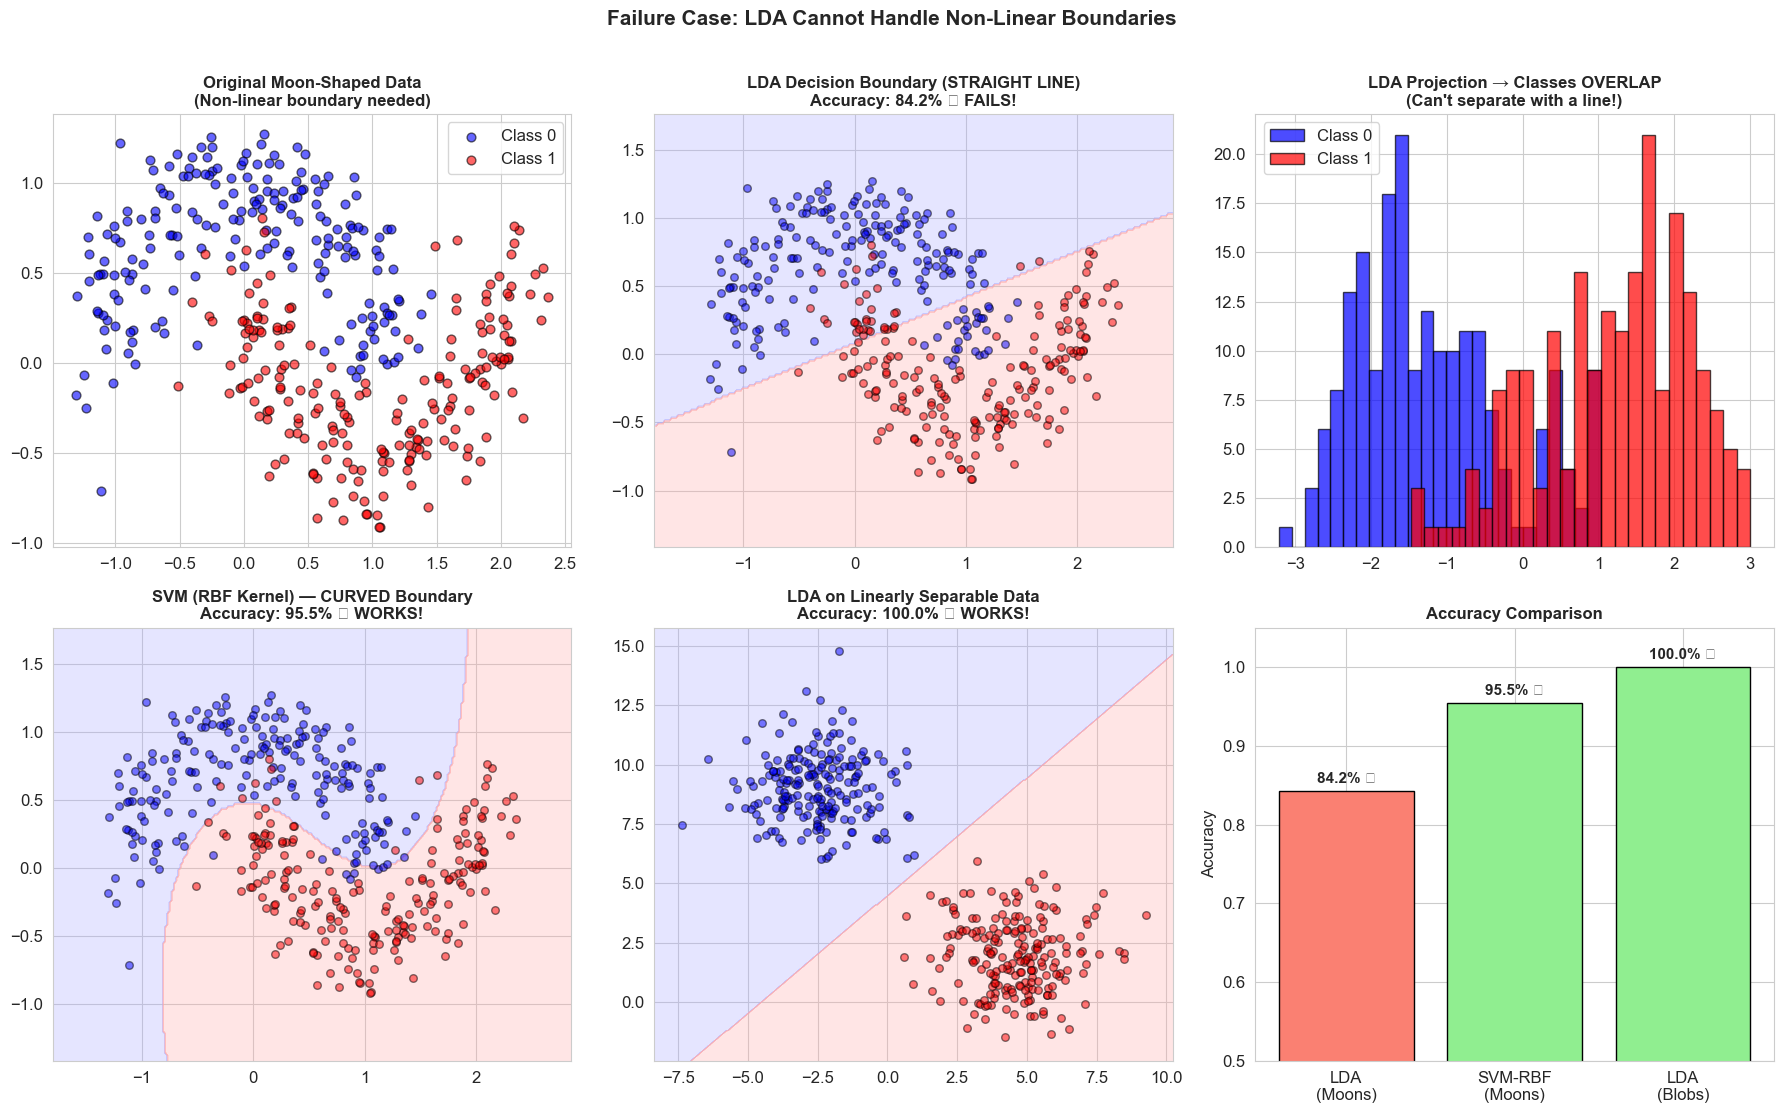


📖 LESSON LEARNED:
   • LDA can ONLY draw straight-line boundaries (linear)
   • If your data has curved/circular/spiral patterns → LDA will fail
   • Solution: Use SVM with RBF kernel, Random Forest, or Neural Networks
   • Always VISUALIZE your data first to check if classes are linearly separable!


In [ ]:
# ============================================================
# FAILURE CASE 3: NON-LINEAR CLASS BOUNDARIES
# ============================================================
# This is LDA's BIGGEST weakness. If classes can't be separated by a
# straight line, LDA will fail — no matter how good the data quality is.
#
# We demonstrate with "make_moons" — two crescent-shaped classes that
# interleave. No straight line can separate them!

from sklearn.svm import SVC

X_moons, y_moons = make_moons(n_samples=400, noise=0.2, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# --- Row 1: The Problem ---
# Original data
axes[0, 0].scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1],
                  c='blue', alpha=0.6, s=40, edgecolors='k', label='Class 0')
axes[0, 0].scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1],
                  c='red', alpha=0.6, s=40, edgecolors='k', label='Class 1')
axes[0, 0].set_title('Original Moon-Shaped Data\n(Non-linear boundary needed)', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# LDA tries to separate with a straight line → fails
lda_moons = LinearDiscriminantAnalysis()
lda_moons.fit(X_moons, y_moons)

# Decision boundary for LDA
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z_lda = lda_moons.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0, 1].contourf(xx, yy, Z_lda, alpha=0.3, cmap=ListedColormap(['#AAAAFF', '#FFAAAA']))
axes[0, 1].scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], c='blue', alpha=0.5, s=30, edgecolors='k')
axes[0, 1].scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], c='red', alpha=0.5, s=30, edgecolors='k')
acc_lda_moon = lda_moons.score(X_moons, y_moons)
axes[0, 1].set_title(f'LDA Decision Boundary (STRAIGHT LINE)\nAccuracy: {acc_lda_moon:.1%} ❌ FAILS!',
                    fontsize=12, fontweight='bold')

# LDA projection (1D) — classes overlap badly
X_moons_lda = lda_moons.transform(X_moons)
axes[0, 2].hist(X_moons_lda[y_moons == 0], bins=25, alpha=0.7, color='blue', label='Class 0', edgecolor='black')
axes[0, 2].hist(X_moons_lda[y_moons == 1], bins=25, alpha=0.7, color='red', label='Class 1', edgecolor='black')
axes[0, 2].set_title('LDA Projection → Classes OVERLAP\n(Can\'t separate with a line!)',
                    fontsize=12, fontweight='bold')
axes[0, 2].legend()

# --- Row 2: The Solution (SVM with RBF kernel) ---
# SVM with RBF kernel can draw CURVED boundaries
svm_rbf = SVC(kernel='rbf', gamma='auto')
svm_rbf.fit(X_moons, y_moons)

Z_svm = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1, 0].contourf(xx, yy, Z_svm, alpha=0.3, cmap=ListedColormap(['#AAAAFF', '#FFAAAA']))
axes[1, 0].scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], c='blue', alpha=0.5, s=30, edgecolors='k')
axes[1, 0].scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], c='red', alpha=0.5, s=30, edgecolors='k')
acc_svm = svm_rbf.score(X_moons, y_moons)
axes[1, 0].set_title(f'SVM (RBF Kernel) — CURVED Boundary\nAccuracy: {acc_svm:.1%} ✅ WORKS!',
                    fontsize=12, fontweight='bold')

# Also show a linearly-separable dataset where LDA works great
from sklearn.datasets import make_blobs
X_blobs, y_blobs = make_blobs(n_samples=400, centers=2, cluster_std=1.5, random_state=42)

lda_blobs = LinearDiscriminantAnalysis()
lda_blobs.fit(X_blobs, y_blobs)

xx2, yy2 = np.meshgrid(np.arange(X_blobs[:, 0].min()-1, X_blobs[:, 0].max()+1, 0.05),
                        np.arange(X_blobs[:, 1].min()-1, X_blobs[:, 1].max()+1, 0.05))
Z_blobs = lda_blobs.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

axes[1, 1].contourf(xx2, yy2, Z_blobs, alpha=0.3, cmap=ListedColormap(['#AAAAFF', '#FFAAAA']))
axes[1, 1].scatter(X_blobs[y_blobs == 0, 0], X_blobs[y_blobs == 0, 1], c='blue', alpha=0.5, s=30, edgecolors='k')
axes[1, 1].scatter(X_blobs[y_blobs == 1, 0], X_blobs[y_blobs == 1, 1], c='red', alpha=0.5, s=30, edgecolors='k')
acc_blobs = lda_blobs.score(X_blobs, y_blobs)
axes[1, 1].set_title(f'LDA on Linearly Separable Data\nAccuracy: {acc_blobs:.1%} ✅ WORKS!',
                    fontsize=12, fontweight='bold')

# Summary comparison bar chart
methods = ['LDA\n(Moons)', 'SVM-RBF\n(Moons)', 'LDA\n(Blobs)']
accs = [acc_lda_moon, acc_svm, acc_blobs]
bar_colors = ['salmon', 'lightgreen', 'lightgreen']
axes[1, 2].bar(methods, accs, color=bar_colors, edgecolor='black')
axes[1, 2].set_ylim(0.5, 1.05)
axes[1, 2].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Accuracy')
for i, v in enumerate(accs):
    symbol = "❌" if v < 0.9 else "✅"
    axes[1, 2].text(i, v + 0.01, f'{v:.1%} {symbol}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Failure Case: LDA Cannot Handle Non-Linear Boundaries', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📖 LESSON LEARNED:")
print("   • LDA can ONLY draw straight-line boundaries (linear)")
print("   • If your data has curved/circular/spiral patterns → LDA will fail")
print("   • Solution: Use SVM with RBF kernel, Random Forest, or Neural Networks")
print("   • Always VISUALIZE your data first to check if classes are linearly separable!")

In [ ]:
# ============================================================
# FAILURE CASE 4: SINGULAR S_W (More features than samples)
# ============================================================
# When you have MORE features than data points, S_W becomes "singular"
# (cannot be inverted), and standard LDA crashes.
#
# This is common in:
#   - Genomics (20,000 genes, only 50 patients)
#   - Text analysis (10,000 words, only 100 documents)
#   - Medical imaging (millions of pixels, few scans)

np.random.seed(42)

# Extreme case: 20 samples but 50 features!
n_samples_small = 20
n_features_big = 50

X_singular = np.random.randn(n_samples_small, n_features_big)
y_singular = np.array([0] * 10 + [1] * 10)

print("=" * 60)
print("FAILURE CASE: More features than samples (d > N)")
print("=" * 60)
print(f"  Samples (N): {n_samples_small}")
print(f"  Features (d): {n_features_big}")
print(f"  N < d? → {n_samples_small} < {n_features_big} = YES ⚠️")

# Try standard LDA — it will use sklearn's built-in solver (which handles this)
# But let's show what happens if we try to compute S_W^{-1} manually:
print(f"\n--- Manual computation (what happens under the hood) ---")

mean_0 = X_singular[y_singular == 0].mean(axis=0)
mean_1 = X_singular[y_singular == 1].mean(axis=0)

S_W_singular = np.zeros((n_features_big, n_features_big))
for c in [0, 1]:
    X_c = X_singular[y_singular == c]
    diff = X_c - X_c.mean(axis=0)
    S_W_singular += diff.T @ diff

# Check if S_W is singular
rank = np.linalg.matrix_rank(S_W_singular)
print(f"  S_W matrix shape: {S_W_singular.shape}")
print(f"  S_W rank: {rank} (needs to be {n_features_big} for invertibility)")
print(f"  Is S_W invertible? {'YES ✅' if rank == n_features_big else 'NO ❌ — SINGULAR!'}")

try:
    S_W_inv = np.linalg.inv(S_W_singular)
    print("  S_W^{-1} computed successfully")
except np.linalg.LinAlgError:
    print("  ❌ np.linalg.inv() FAILED — matrix is singular!")

# THE FIX: Regularized LDA (sklearn does this automatically with 'lsqr' solver)
print(f"\n--- The Fix: Regularized LDA (shrinkage) ---")
lda_reg = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_reg.fit(X_singular, y_singular)
acc_reg = cross_val_score(lda_reg, X_singular, y_singular, cv=3).mean()
print(f"  Regularized LDA (solver='lsqr', shrinkage='auto') → Works! ✅")
print(f"  Cross-validated accuracy: {acc_reg:.2%}")

# Another fix: PCA first to reduce dimensions, then LDA
pca_first = PCA(n_components=min(n_samples_small - 2, 10))  # reduce to < N
X_pca_reduced = pca_first.fit_transform(X_singular)
lda_after_pca = LinearDiscriminantAnalysis()
lda_after_pca.fit(X_pca_reduced, y_singular)
print(f"\n  PCA({X_pca_reduced.shape[1]} components) → LDA → Also works! ✅")
print(f"\n📖 LESSON: When N < d, use regularized LDA or apply PCA first to reduce dimensions.")

FAILURE CASE: More features than samples (d > N)
  Samples (N): 20
  Features (d): 50
  N < d? → 20 < 50 = YES ⚠️

--- Manual computation (what happens under the hood) ---
  S_W matrix shape: (50, 50)
  S_W rank: 18 (needs to be 50 for invertibility)
  Is S_W invertible? NO ❌ — SINGULAR!
  S_W^{-1} computed successfully

--- The Fix: Regularized LDA (shrinkage) ---
  Regularized LDA (solver='lsqr', shrinkage='auto') → Works! ✅
  Cross-validated accuracy: 40.48%

  PCA(10 components) → LDA → Also works! ✅

📖 LESSON: When N < d, use regularized LDA or apply PCA first to reduce dimensions.


## 15b. PCA Assumptions (Often Overlooked!)

---


PCA is sometimes treated as "assumption-free," but it does make implicit assumptions:

### PCA Assumptions

| # | Assumption | What it means |
|---|-----------|---------------|
| 1 | **Linearity** | The data structure can be captured by linear combinations of features. Non-linear relationships are invisible to PCA. |
| 2 | **Variance = Importance** | Directions of highest variance contain the most useful information. If noise has high variance, PCA will keep the noise! |
| 3 | **Features on comparable scales** | PCA is sensitive to feature scaling. A feature in thousands (income) will dominate one in decimals (GPA) unless standardized. |
| 4 | **Orthogonality** | Principal components are forced to be orthogonal (uncorrelated). Real data structure may not be orthogonal. |
| 5 | **Large sample size** | With very few samples relative to features, PCA can overfit to noise. |

---

### Side-by-Side: LDA vs PCA Assumptions

| Assumption | LDA | PCA |
|-----------|-----|-----|
| **Needs class labels** | Yes (supervised) | No (unsupervised) |
| **Normal distribution per class** | Assumes it | No assumption |
| **Equal covariance across classes** | Assumes it | Not applicable |
| **Linearity** | Linear boundaries only | Linear projections only |
| **Feature scaling needed** | Recommended | Critical (variance-based) |
| **$S_W$ must be invertible** | Required ($N > d$) | Uses SVD, handles rank-deficient data |
| **Variance = useful signal** | No — uses class separability | Yes — core assumption |
| **Orthogonal components** | Not required | Forced orthogonality |

---

### When to Use Which — Decision Guide

| Scenario | Use **PCA** | Use **LDA** |
|----------|:-----------:|:-----------:|
| No class labels (unsupervised) | **Yes** | Cannot use |
| Classification with labels | Maybe | **Yes** |
| Data exploration / visualization | **Yes** | Only if labels exist |
| Compression / reconstruction | **Yes** | Not designed for this |
| Non-normal class distributions | **Yes** (more robust) | Risky |
| Unequal covariance per class | **Yes** | Risky — consider QDA |
| $N < d$ (few samples, many features) | **Yes** | Breaks unless regularized |
| Many classes, few features | **Yes** (no component cap) | Limited to $C-1$ components |
| High-dim noise removal for classification | Possible | **Yes** (better — class-aware) |
| Before clustering (K-Means, DBSCAN) | **Yes** | Cannot use (no labels for clustering) |
| Anomaly / outlier detection | **Yes** (captures variance) | Not suitable |

> **Rule of thumb:** If you have labels and want to classify → try LDA first. For everything else → PCA.

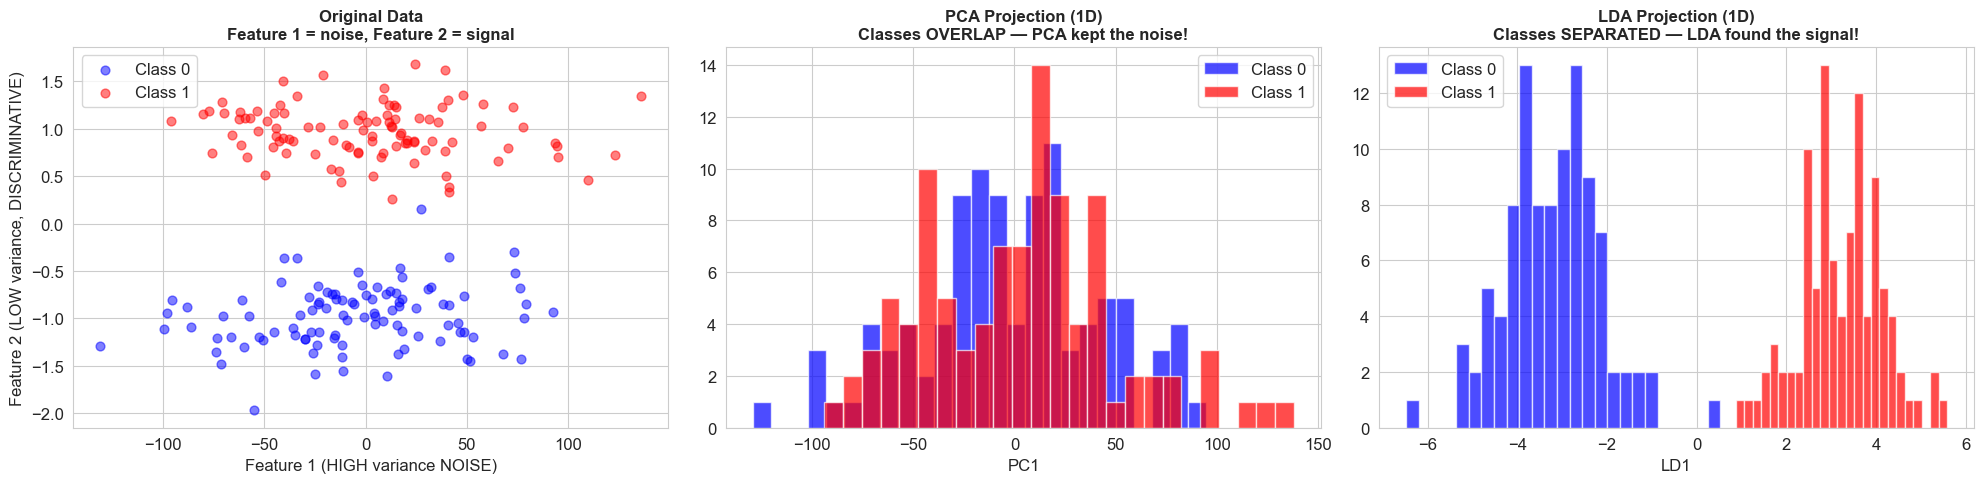

Feature variances: Feature 1 (noise) = 2156.1,  Feature 2 (signal) = 1.04

PCA kept the HIGH-variance noise → Classification accuracy: 54.50%
LDA found the DISCRIMINATIVE direction → Classification accuracy: 99.50%

⚠️  PCA assumption 'high variance = important' FAILS here!
✅  LDA doesn't care about variance — it cares about CLASS SEPARATION.


In [ ]:
# DEMO: PCA's "Variance = Importance" assumption can be WRONG for classification
# While LDA's class-aware approach avoids this pitfall

np.random.seed(42)

# Create a dataset where high-variance feature is NOISE and low-variance feature is DISCRIMINATIVE
n = 200
# Feature 1: HIGH variance NOISE (useless for classification)
noise_feat = np.random.normal(0, 50, n)
# Feature 2: LOW variance but PERFECTLY separates the classes
class_labels = np.array([0] * (n // 2) + [1] * (n // 2))
discriminative_feat = np.where(class_labels == 0,
                                np.random.normal(-1, 0.3, n),
                                np.random.normal(1, 0.3, n))

X_trap = np.column_stack([noise_feat, discriminative_feat])

# Apply PCA and LDA
pca_trap = PCA(n_components=1)
X_pca_trap = pca_trap.fit_transform(X_trap)

lda_trap = LinearDiscriminantAnalysis(n_components=1)
X_lda_trap = lda_trap.fit_transform(X_trap, class_labels)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Original data
axes[0].scatter(X_trap[class_labels == 0, 0], X_trap[class_labels == 0, 1],
               c='blue', alpha=0.5, s=40, label='Class 0')
axes[0].scatter(X_trap[class_labels == 1, 0], X_trap[class_labels == 1, 1],
               c='red', alpha=0.5, s=40, label='Class 1')
axes[0].set_xlabel('Feature 1 (HIGH variance NOISE)')
axes[0].set_ylabel('Feature 2 (LOW variance, DISCRIMINATIVE)')
axes[0].set_title('Original Data\nFeature 1 = noise, Feature 2 = signal', fontsize=12, fontweight='bold')
axes[0].legend()

# PCA projection — captures noise!
axes[1].hist(X_pca_trap[class_labels == 0], bins=25, alpha=0.7, color='blue', label='Class 0')
axes[1].hist(X_pca_trap[class_labels == 1], bins=25, alpha=0.7, color='red', label='Class 1')
axes[1].set_title('PCA Projection (1D)\nClasses OVERLAP — PCA kept the noise!', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].legend()

# LDA projection — captures discrimination!
axes[2].hist(X_lda_trap[class_labels == 0], bins=25, alpha=0.7, color='blue', label='Class 0')
axes[2].hist(X_lda_trap[class_labels == 1], bins=25, alpha=0.7, color='red', label='Class 1')
axes[2].set_title('LDA Projection (1D)\nClasses SEPARATED — LDA found the signal!', fontsize=12, fontweight='bold')
axes[2].set_xlabel('LD1')
axes[2].legend()

plt.tight_layout()
plt.show()

# Classification accuracy
from sklearn.linear_model import LogisticRegression
acc_pca = cross_val_score(Pipeline([('pca', PCA(1)), ('lr', LogisticRegression())]),
                          X_trap, class_labels, cv=5).mean()
acc_lda = cross_val_score(Pipeline([('lda', LinearDiscriminantAnalysis(n_components=1)),
                                     ('lr', LogisticRegression())]),
                          X_trap, class_labels, cv=5).mean()

print(f"Feature variances: Feature 1 (noise) = {X_trap[:, 0].var():.1f},  Feature 2 (signal) = {X_trap[:, 1].var():.2f}")
print(f"\nPCA kept the HIGH-variance noise → Classification accuracy: {acc_pca:.2%}")
print(f"LDA found the DISCRIMINATIVE direction → Classification accuracy: {acc_lda:.2%}")
print(f"\n⚠️  PCA assumption 'high variance = important' FAILS here!")
print(f"✅  LDA doesn't care about variance — it cares about CLASS SEPARATION.")

## 16. Multi-Class LDA — Classic Iris Dataset (End-to-End)

---


The Iris dataset is the **canonical example** for LDA:
- 3 classes (Setosa, Versicolor, Virginica)
- 4 features (sepal length/width, petal length/width)
- LDA can reduce to 2 components → beautiful 2D visualization

Iris LDA: 4D → 2D
Accuracy: 0.9778

Explained variance ratio: [0.9881565 0.0118435]


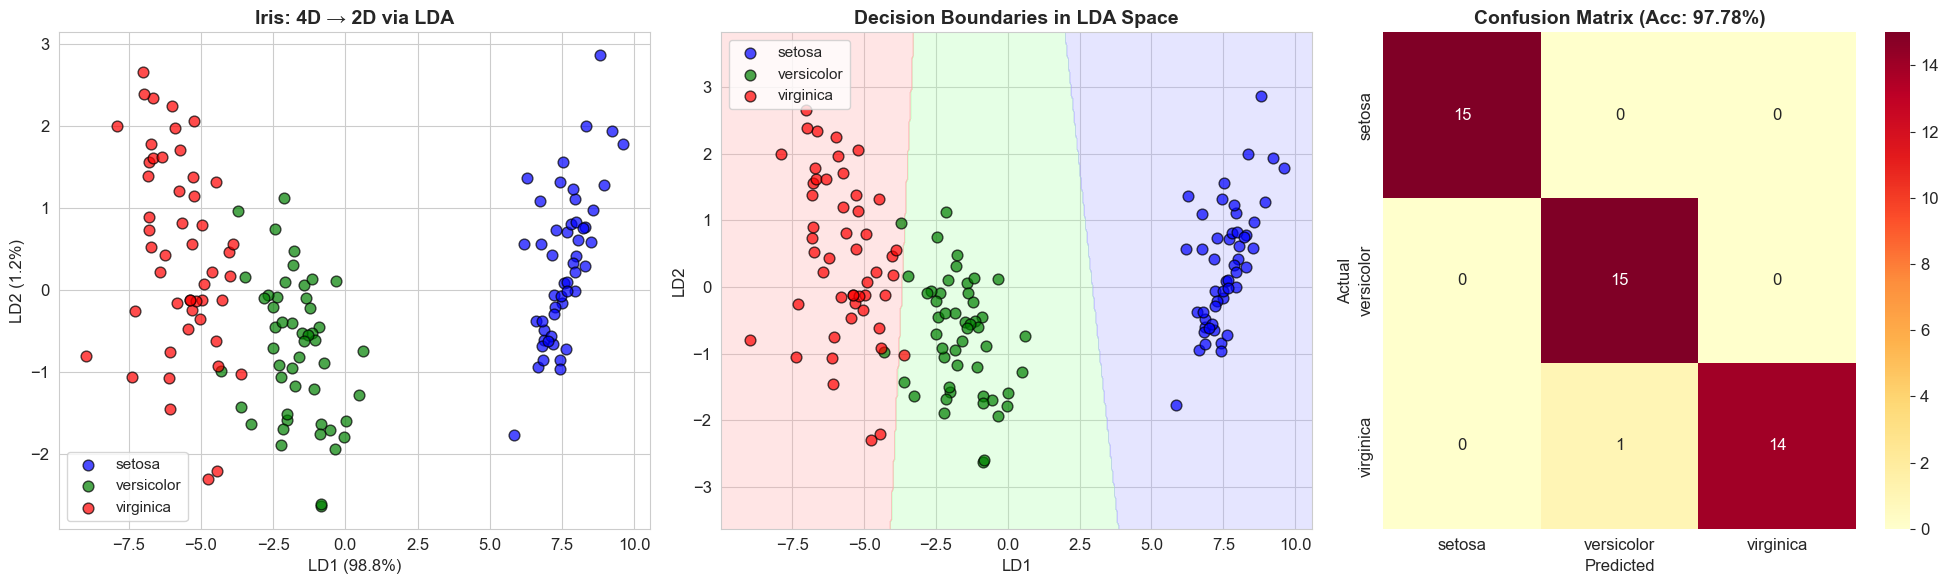

In [ ]:
# Load Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Train-test split FIRST (avoid data leakage)
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

# Standardize — fit on training data only
scaler_iris = StandardScaler()
X_tr_i_scaled = scaler_iris.fit_transform(X_tr_i)
X_te_i_scaled = scaler_iris.transform(X_te_i)

# Apply LDA — fit on training data only
lda_iris = LinearDiscriminantAnalysis(n_components=2)
X_tr_i = lda_iris.fit_transform(X_tr_i_scaled, y_tr_i)
X_te_i = lda_iris.transform(X_te_i_scaled)

# Also transform ALL data for visualization
X_iris_scaled = scaler_iris.transform(X_iris)
X_iris_lda = lda_iris.transform(X_iris_scaled)

# Train classifier
clf_iris = LogisticRegression(random_state=42, max_iter=1000)
clf_iris.fit(X_tr_i, y_tr_i)
y_pred_i = clf_iris.predict(X_te_i)

print(f"Iris LDA: {X_iris.shape[1]}D → {X_iris_lda.shape[1]}D")
print(f"Accuracy: {accuracy_score(y_te_i, y_pred_i):.4f}")
print(f"\nExplained variance ratio: {lda_iris.explained_variance_ratio_}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. LDA 2D scatter
colors_iris = ['blue', 'green', 'red']
for i, name in enumerate(iris.target_names):
    mask = y_iris == i
    axes[0].scatter(X_iris_lda[mask, 0], X_iris_lda[mask, 1],
                   c=colors_iris[i], alpha=0.7, s=60, edgecolors='k', label=name)
axes[0].set_xlabel(f'LD1 ({lda_iris.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'LD2 ({lda_iris.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Iris: 4D → 2D via LDA', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# 2. Decision boundaries in LDA space
h = 0.05
x_min, x_max = X_iris_lda[:, 0].min() - 1, X_iris_lda[:, 0].max() + 1
y_min, y_max = X_iris_lda[:, 1].min() - 1, X_iris_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

clf_full = LogisticRegression(random_state=42, max_iter=1000)
clf_full.fit(X_iris_lda, y_iris)
Z = clf_full.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#AAAAFF', '#AAFFAA', '#FFAAAA'])
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for i, name in enumerate(iris.target_names):
    mask = y_iris == i
    axes[1].scatter(X_iris_lda[mask, 0], X_iris_lda[mask, 1],
                   c=colors_iris[i], alpha=0.7, s=60, edgecolors='k', label=name)
axes[1].set_title('Decision Boundaries in LDA Space', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend(fontsize=11)

# 3. Confusion matrix heatmap
cm_iris = confusion_matrix(y_te_i, y_pred_i)
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[2].set_title(f'Confusion Matrix (Acc: {accuracy_score(y_te_i, y_pred_i):.2%})',
                 fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 17. Hyperparameter Tuning — Choosing the Optimal Number of Components

---


The key hyperparameter in LDA is **`n_components`** — how many discriminant axes to keep.

Guidelines:
- Maximum is $\min(C - 1, d)$
- Use **explained variance ratio** (discriminability ratio) to see how much each component contributes
- Use **cross-validated accuracy** to find the optimal number

Digits dataset: (1797, 64) → 10 classes
Max LDA components: min(10-1, 64) = 9


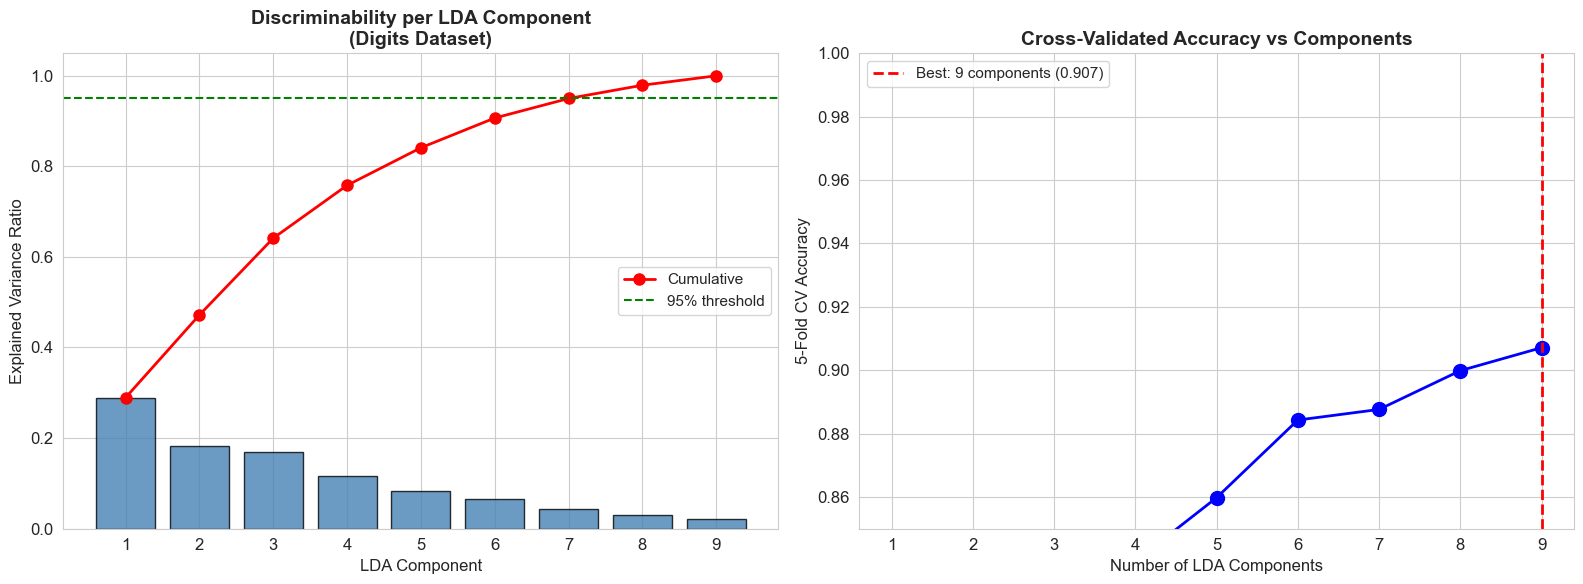


📊 Explained variance ratios: [0.289 0.183 0.17  0.117 0.083 0.066 0.043 0.029 0.021]
📊 Cumulative: [0.289 0.472 0.641 0.758 0.841 0.907 0.95  0.979 1.   ]

✅ Best n_components = 9 (CV accuracy: 0.9071)
   Using 9 of 64 original features — 14.1% of original dimensionality!

💡 PRACTICAL GUIDELINE:
   1. Look at the cumulative explained ratio — aim for ≥95%
   2. Use cross-validation to confirm the best number
   3. When in doubt, start with C-1 components (the maximum)


In [ ]:
# Using the Digits dataset (10 classes, 64 features) → max 9 LDA components
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

print(f"Digits dataset: {X_dig.shape} → {len(np.unique(y_dig))} classes")
print(f"Max LDA components: min(10-1, 64) = 9")

# Standardize
scaler_dig = StandardScaler()
X_dig_scaled = scaler_dig.fit_transform(X_dig)

# Fit full LDA to get explained variance ratios
lda_full = LinearDiscriminantAnalysis(n_components=9)
lda_full.fit(X_dig_scaled, y_dig)
evr = lda_full.explained_variance_ratio_

# Cross-validated accuracy for different n_components
n_components_range = range(1, 10)
cv_scores = []

for n in n_components_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis(n_components=n)),
        ('clf', LogisticRegression(random_state=42, max_iter=2000))
    ])
    scores = cross_val_score(pipe, X_dig, y_dig, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Explained variance ratio
axes[0].bar(range(1, 10), evr, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, 10), np.cumsum(evr), 'ro-', linewidth=2, markersize=8, label='Cumulative')
axes[0].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[0].set_xlabel('LDA Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Discriminability per LDA Component\n(Digits Dataset)', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 10))
axes[0].legend(fontsize=11)

# 2. Cross-validated accuracy vs n_components
axes[1].plot(list(n_components_range), cv_scores, 'bo-', linewidth=2, markersize=10)
best_n = list(n_components_range)[np.argmax(cv_scores)]
axes[1].axvline(x=best_n, color='red', linestyle='--', linewidth=2,
               label=f'Best: {best_n} components ({max(cv_scores):.3f})')
axes[1].set_xlabel('Number of LDA Components', fontsize=12)
axes[1].set_ylabel('5-Fold CV Accuracy', fontsize=12)
axes[1].set_title('Cross-Validated Accuracy vs Components', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(n_components_range))
axes[1].legend(fontsize=11)
axes[1].set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

print(f"\n📊 Explained variance ratios: {evr.round(3)}")
print(f"📊 Cumulative: {np.cumsum(evr).round(3)}")
print(f"\n✅ Best n_components = {best_n} (CV accuracy: {max(cv_scores):.4f})")
print(f"   Using {best_n} of 64 original features — {best_n/64:.1%} of original dimensionality!")
print(f"\n💡 PRACTICAL GUIDELINE:")
print(f"   1. Look at the cumulative explained ratio — aim for ≥95%")
print(f"   2. Use cross-validation to confirm the best number")
print(f"   3. When in doubt, start with C-1 components (the maximum)")

## Summary & Key Takeaways

---


### What is LDA?
A **supervised** dimensionality reduction technique that finds the projection maximizing **between-class separation** while minimizing **within-class scatter**.

### The Math in One Line
$$\mathbf{w}^* = \arg\max_{\mathbf{w}} \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}} \implies S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$$

### When to Use LDA

| Scenario | Use LDA? | Why? |
|----------|----------|------|
| Classification + many features | ✅ Yes | Reduces noise, prevents overfitting |
| Need interpretable features | ✅ Yes | LDA components have clear meaning |
| Multi-class visualization | ✅ Yes | Projects to C-1 dims for plotting |
| Non-linear class boundaries | ❌ No | Use Kernel LDA or non-linear methods |
| Unsupervised (no labels) | ❌ No | Use PCA instead |
| Very small sample size | ⚠️ Caution | S_W may be singular; use regularized LDA |
| Unequal class covariances | ⚠️ Caution | Consider QDA instead |

### Key Formulas Cheat Sheet

| Formula | Description |
|---------|-------------|
| $S_W = \sum_{i} \sum_{x \in C_i} (x-\mu_i)(x-\mu_i)^T$ | Within-class scatter |
| $S_B = \sum_{i} N_i (\mu_i - \mu)(\mu_i - \mu)^T$ | Between-class scatter |
| $J(w) = \frac{w^T S_B w}{w^T S_W w}$ | Fisher's criterion |
| Max components $= \min(C-1, d)$ | Dimensionality constraint |

### What We Demonstrated
1. **Theory** → Full derivation from intuition to eigenvalue problem
2. **From Scratch** → Built LDA class in pure NumPy
3. **Real-Life** → Customer segmentation, breast cancer diagnosis
4. **sklearn Pipeline** → Production-ready code
5. **LDA vs PCA** → Supervised beats unsupervised for classification
6. **With vs Without LDA** → Dramatic improvement on high-dimensional data
7. **Assumptions** → When LDA works and when it fails
8. **Hyperparameter Tuning** → How to choose n_components

---
*Notebook created for teaching Linear Discriminant Analysis — from freshers to experienced practitioners.*